<a href="https://colab.research.google.com/github/KeerthanaSistla/Research/blob/main/GLOBAL_ATTENTION_NETWORK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# HYBRID CNN + GLOBAL ATTENTION NETWORK
# Fashion-MNIST Version
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# ============================================================
# DATASET
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

# ============================================================
# TRANSFORMER BLOCK
# ============================================================

class TransformerBlock(nn.Module):

    def __init__(self, dim, heads=4, dropout=0.1):
        super().__init__()

        self.norm1 = nn.LayerNorm(dim)

        self.attention = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm2 = nn.LayerNorm(dim)

        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 4, dim)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        # ========================================
        # ATTENTION
        # ========================================

        residual = x

        x_norm = self.norm1(x)

        attn_output, attn_weights = self.attention(
            x_norm,
            x_norm,
            x_norm
        )

        x = residual + self.dropout(attn_output)

        # ========================================
        # FEED FORWARD
        # ========================================

        residual = x

        x_norm = self.norm2(x)

        ffn_output = self.ffn(x_norm)

        x = residual + self.dropout(ffn_output)

        return x, attn_weights

# ============================================================
# MAIN MODEL
# ============================================================

class FashionAttentionNet(nn.Module):

    def __init__(self):
        super().__init__()

        # ========================================
        # CNN FEATURE EXTRACTOR
        # ========================================

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.GELU(),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.GELU()
        )

        # ========================================
        # POSITIONAL EMBEDDING
        # ========================================

        self.pos_embedding = nn.Parameter(
            torch.randn(1, 28 * 28, 64)
        )

        # ========================================
        # TRANSFORMER BLOCKS
        # ========================================

        self.block1 = TransformerBlock(
            dim=64,
            heads=4
        )

        self.block2 = TransformerBlock(
            dim=64,
            heads=4
        )

        # ========================================
        # CLASSIFIER
        # ========================================

        self.classifier = nn.Sequential(

            nn.Linear(64, 128),

            nn.GELU(),

            nn.Dropout(0.2),

            nn.Linear(128, 10)
        )

        # Store attention maps
        self.attention_maps = None

    def forward(self, x):

        # ========================================
        # CNN FEATURES
        # ========================================

        x = self.conv(x)

        # Shape:
        # [B, 64, 28, 28]

        B, C, H, W = x.shape

        # ========================================
        # FLATTEN TO TOKENS
        # ========================================

        x = x.view(B, C, H * W)

        x = x.permute(0, 2, 1)

        # Shape:
        # [B, 784, 64]

        # ========================================
        # ADD POSITIONAL INFORMATION
        # ========================================

        x = x + self.pos_embedding

        # ========================================
        # TRANSFORMER BLOCKS
        # ========================================

        x, attn1 = self.block1(x)

        x, attn2 = self.block2(x)

        self.attention_maps = attn2

        # ========================================
        # GLOBAL POOLING
        # ========================================

        x = x.mean(dim=1)

        # ========================================
        # CLASSIFICATION
        # ========================================

        x = self.classifier(x)

        return x

# ============================================================
# INITIALIZE MODEL
# ============================================================

model = FashionAttentionNet().to(device)

# ============================================================
# LOSS FUNCTION + OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

# ============================================================
# TRAINING
# ============================================================

epochs = 15

for epoch in range(epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {running_loss/len(train_loader):.4f} "
        f"Train Accuracy: {train_acc:.2f}%"
    )

# ============================================================
# TESTING
# ============================================================

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total

print("\n===================================")
print(f"FINAL TEST ACCURACY: {test_acc:.2f}%")
print("===================================")

Using Device: cuda


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.80MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.9MB/s]


Epoch [1/15] Loss: 0.8722 Train Accuracy: 67.17%
Epoch [2/15] Loss: 0.4688 Train Accuracy: 82.92%
Epoch [3/15] Loss: 0.4007 Train Accuracy: 85.10%
Epoch [4/15] Loss: 0.3635 Train Accuracy: 86.51%
Epoch [5/15] Loss: 0.3376 Train Accuracy: 87.48%
Epoch [6/15] Loss: 0.3199 Train Accuracy: 88.14%
Epoch [7/15] Loss: 0.3004 Train Accuracy: 88.72%


KeyboardInterrupt: 

In [ ]:
# ============================================================
# ISPRA-Net v2
# Interpretable Sparse Pixel Relational Attention Network
# ============================================================
#
# Improvements Added:
#
# 1. Patch Tokens instead of raw pixels
# 2. CLS token
# 3. Relative positional bias
# 4. Sparse Top-K attention
# 5. Attention dropout
# 6. Validation accuracy every epoch
# 7. Better transformer structure
#
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

# ============================================================
# HYPERPARAMETERS
# ============================================================

IMAGE_SIZE = 28
PATCH_SIZE = 4

NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2

EMBED_DIM = 96

NUM_HEADS = 4

TOP_K = 8

NUM_CLASSES = 10

BATCH_SIZE = 64

EPOCHS = 15

LEARNING_RATE = 1e-3

# ============================================================
# DATASET
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ============================================================
# PATCH EMBEDDING
# ============================================================

class PatchEmbedding(nn.Module):

    def __init__(
        self,
        in_channels=1,
        embed_dim=96,
        patch_size=4
    ):
        super().__init__()

        self.proj = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):

        x = self.proj(x)

        # Shape:
        # [B, EMBED_DIM, H', W']

        B, C, H, W = x.shape

        x = x.flatten(2)

        x = x.transpose(1, 2)

        # Shape:
        # [B, NUM_PATCHES, EMBED_DIM]

        return x

# ============================================================
# SPARSE RELATIONAL ATTENTION
# ============================================================

class SparseRelationalAttention(nn.Module):

    def __init__(
        self,
        dim,
        heads=4,
        top_k=8,
        dropout=0.1,
        num_tokens=50
    ):
        super().__init__()

        self.dim = dim
        self.heads = heads
        self.top_k = top_k

        self.head_dim = dim // heads

        # QKV projections
        self.query = nn.Linear(dim, dim)
        self.key   = nn.Linear(dim, dim)
        self.value = nn.Linear(dim, dim)

        self.proj = nn.Linear(dim, dim)

        self.dropout = nn.Dropout(dropout)

        # Relative positional bias
        self.relative_bias = nn.Parameter(
            torch.randn(heads, num_tokens, num_tokens)
        )

        # Store attention maps
        self.last_attention = None

    def forward(self, x):

        B, N, D = x.shape

        # ====================================================
        # QKV
        # ====================================================

        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        # ====================================================
        # MULTI-HEAD RESHAPE
        # ====================================================

        Q = Q.view(B, N, self.heads, self.head_dim)
        K = K.view(B, N, self.heads, self.head_dim)
        V = V.view(B, N, self.heads, self.head_dim)

        Q = Q.permute(0, 2, 1, 3)
        K = K.permute(0, 2, 1, 3)
        V = V.permute(0, 2, 1, 3)

        # ====================================================
        # ATTENTION SCORES
        # ====================================================

        attention = torch.matmul(
            Q,
            K.transpose(-2, -1)
        )

        attention = attention / (self.head_dim ** 0.5)

        # ====================================================
        # ADD RELATIVE POSITIONAL BIAS
        # ====================================================

        attention = attention + self.relative_bias[:, :N, :N]

        # ====================================================
        # SPARSE TOP-K ATTENTION
        # ====================================================

        topk_values, topk_indices = torch.topk(
            attention,
            k=min(self.top_k, N),
            dim=-1
        )

        sparse_attention = torch.full_like(
            attention,
            float('-inf')
        )

        sparse_attention.scatter_(
            -1,
            topk_indices,
            topk_values
        )

        attention = F.softmax(
            sparse_attention,
            dim=-1
        )

        # ====================================================
        # ATTENTION DROPOUT
        # ====================================================

        attention = self.dropout(attention)

        # ====================================================
        # STORE ATTENTION MAPS
        # ====================================================

        self.last_attention = attention.detach().cpu()

        # ====================================================
        # APPLY ATTENTION
        # ====================================================

        out = torch.matmul(attention, V)

        # ====================================================
        # RESTORE SHAPE
        # ====================================================

        out = out.permute(0, 2, 1, 3)

        out = out.contiguous().view(B, N, D)

        out = self.proj(out)

        return out

# ============================================================
# TRANSFORMER BLOCK
# ============================================================

class ISPRA_Block(nn.Module):

    def __init__(
        self,
        dim,
        heads=4,
        top_k=8,
        dropout=0.1,
        num_tokens=50
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(dim)

        self.attention = SparseRelationalAttention(
            dim=dim,
            heads=heads,
            top_k=top_k,
            dropout=dropout,
            num_tokens=num_tokens
        )

        self.norm2 = nn.LayerNorm(dim)

        self.ffn = nn.Sequential(

            nn.Linear(dim, dim * 4),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(dim * 4, dim)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        # ====================================================
        # ATTENTION
        # ====================================================

        residual = x

        x_norm = self.norm1(x)

        x = residual + self.dropout(
            self.attention(x_norm)
        )

        # ====================================================
        # FEED FORWARD
        # ====================================================

        residual = x

        x_norm = self.norm2(x)

        x = residual + self.dropout(
            self.ffn(x_norm)
        )

        return x

# ============================================================
# MAIN MODEL
# ============================================================

class ISPRA_Net(nn.Module):

    def __init__(self):
        super().__init__()

        # ====================================================
        # PATCH EMBEDDING
        # ====================================================

        self.patch_embed = PatchEmbedding(
            in_channels=1,
            embed_dim=EMBED_DIM,
            patch_size=PATCH_SIZE
        )

        # ====================================================
        # CLS TOKEN
        # ====================================================

        self.cls_token = nn.Parameter(
            torch.randn(1, 1, EMBED_DIM)
        )

        # ====================================================
        # TRANSFORMER BLOCKS
        # ====================================================

        self.block1 = ISPRA_Block(
            dim=EMBED_DIM,
            heads=NUM_HEADS,
            top_k=TOP_K,
            num_tokens=NUM_PATCHES + 1
        )

        self.block2 = ISPRA_Block(
            dim=EMBED_DIM,
            heads=NUM_HEADS,
            top_k=TOP_K,
            num_tokens=NUM_PATCHES + 1
        )

        # ====================================================
        # CLASSIFIER
        # ====================================================

        self.classifier = nn.Sequential(

            nn.Linear(EMBED_DIM, 128),

            nn.GELU(),

            nn.Dropout(0.2),

            nn.Linear(128, NUM_CLASSES)
        )

    def forward(self, x):

        # ====================================================
        # PATCH TOKENS
        # ====================================================

        x = self.patch_embed(x)

        B, N, D = x.shape

        # ====================================================
        # ADD CLS TOKEN
        # ====================================================

        cls_tokens = self.cls_token.expand(B, -1, -1)

        x = torch.cat([cls_tokens, x], dim=1)

        # ====================================================
        # TRANSFORMER BLOCKS
        # ====================================================

        x = self.block1(x)

        x = self.block2(x)

        # ====================================================
        # CLS TOKEN FOR CLASSIFICATION
        # ====================================================

        cls_output = x[:, 0]

        # ====================================================
        # CLASSIFICATION
        # ====================================================

        out = self.classifier(cls_output)

        return out

# ============================================================
# INITIALIZE MODEL
# ============================================================

model = ISPRA_Net().to(device)

# ============================================================
# LOSS + OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

# ============================================================
# TRAINING + VALIDATION
# ============================================================

for epoch in range(EPOCHS):

    # ========================================================
    # TRAINING
    # ========================================================

    model.train()

    train_correct = 0
    train_total = 0

    train_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / train_total

    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total

    # ========================================================
    # PRINT METRICS
    # ========================================================

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {train_loss/len(train_loader):.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Acc: {val_acc:.2f}%"
    )

# ============================================================
# FINAL TEST
# ============================================================

print("\n====================================")
print(f"FINAL VALIDATION ACCURACY: {val_acc:.2f}%")
print("====================================")

Using Device: cuda
Epoch [1/15] | Loss: 0.7253 | Train Acc: 73.24% | Val Acc: 81.07%
Epoch [2/15] | Loss: 0.5236 | Train Acc: 80.87% | Val Acc: 82.62%
Epoch [3/15] | Loss: 0.4702 | Train Acc: 82.74% | Val Acc: 83.81%
Epoch [4/15] | Loss: 0.4379 | Train Acc: 83.90% | Val Acc: 85.22%
Epoch [5/15] | Loss: 0.4150 | Train Acc: 84.75% | Val Acc: 86.04%
Epoch [6/15] | Loss: 0.3943 | Train Acc: 85.45% | Val Acc: 86.17%
Epoch [7/15] | Loss: 0.3771 | Train Acc: 86.08% | Val Acc: 86.97%
Epoch [8/15] | Loss: 0.3636 | Train Acc: 86.71% | Val Acc: 86.48%
Epoch [9/15] | Loss: 0.3535 | Train Acc: 86.98% | Val Acc: 86.87%
Epoch [10/15] | Loss: 0.3409 | Train Acc: 87.46% | Val Acc: 88.03%
Epoch [11/15] | Loss: 0.3313 | Train Acc: 87.87% | Val Acc: 88.20%
Epoch [12/15] | Loss: 0.3220 | Train Acc: 88.07% | Val Acc: 87.55%
Epoch [13/15] | Loss: 0.3141 | Train Acc: 88.48% | Val Acc: 88.58%
Epoch [14/15] | Loss: 0.3085 | Train Acc: 88.66% | Val Acc: 88.52%
Epoch [15/15] | Loss: 0.3041 | Train Acc: 88.75% | V

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# ============================================================
# HYPERPARAMETERS
# ============================================================

BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 1e-3

NUM_CLASSES = 10

EMBED_DIM = 64
NUM_HEADS = 4
TOP_K = 8

IMG_SIZE = 28
PATCH_SIZE = 2   # because of pooling

TOKENS = (IMG_SIZE // PATCH_SIZE) ** 2  # 14x14 = 196

# ============================================================
# DATA
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ============================================================
# SPARSE ATTENTION
# ============================================================

class SparsePixelAttention(nn.Module):
    def __init__(self, dim, heads=4, top_k=8):
        super().__init__()

        self.dim = dim
        self.heads = heads
        self.top_k = top_k
        self.head_dim = dim // heads

        self.q = nn.Linear(dim, dim)
        self.k = nn.Linear(dim, dim)
        self.v = nn.Linear(dim, dim)
        self.proj = nn.Linear(dim, dim)

        self.last_attention = None

    def forward(self, x):
        B, N, D = x.shape

        Q = self.q(x)
        K = self.k(x)
        V = self.v(x)

        Q = Q.view(B, N, self.heads, self.head_dim).transpose(1, 2)
        K = K.view(B, N, self.heads, self.head_dim).transpose(1, 2)
        V = V.view(B, N, self.heads, self.head_dim).transpose(1, 2)

        attn = (Q @ K.transpose(-2, -1)) / (self.head_dim ** 0.5)

        topk_val, topk_idx = torch.topk(attn, self.top_k, dim=-1)

        mask = torch.full_like(attn, float("-inf"))
        mask.scatter_(-1, topk_idx, topk_val)

        attn = F.softmax(mask, dim=-1)

        self.last_attention = attn.detach().cpu()

        out = attn @ V

        out = out.transpose(1, 2).contiguous().view(B, N, D)
        return self.proj(out)

# ============================================================
# BLOCK
# ============================================================

class ISPRA_Block(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.norm1 = nn.LayerNorm(dim)
        self.attn = SparsePixelAttention(dim, NUM_HEADS, TOP_K)

        self.norm2 = nn.LayerNorm(dim)

        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, dim)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x

# ============================================================
# MODEL
# ============================================================

class ISPRA_Net(nn.Module):
    def __init__(self):
        super().__init__()

        # CNN STEM (reduces 28x28 → 14x14)
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.GELU(),
            nn.MaxPool2d(2),  # IMPORTANT
            nn.Conv2d(32, EMBED_DIM, 3, padding=1),
            nn.GELU()
        )

        # FIXED positional embedding (196 tokens)
        self.pos_embedding = nn.Parameter(
            torch.randn(1, TOKENS, EMBED_DIM)
        )

        self.block1 = ISPRA_Block(EMBED_DIM)
        self.block2 = ISPRA_Block(EMBED_DIM)

        self.classifier = nn.Sequential(
            nn.Linear(EMBED_DIM, 128),
            nn.GELU(),
            nn.Linear(128, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.conv(x)

        B, C, H, W = x.shape  # [B, 64, 14, 14]

        x = x.view(B, C, H * W).transpose(1, 2)  # [B, 196, 64]

        x = x + self.pos_embedding

        x = self.block1(x)
        x = self.block2(x)

        x = x.mean(dim=1)

        return self.classifier(x)

# ============================================================
# TRAIN
# ============================================================

model = ISPRA_Net().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

for epoch in range(EPOCHS):

    model.train()
    total, correct, loss_sum = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        loss_sum += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1}: Loss={loss_sum/len(train_loader):.4f}, Acc={100*correct/total:.2f}%")

# ============================================================
# TEST
# ============================================================

model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("TEST ACC:", 100 * correct / total)

Using Device: cuda


RuntimeError: The size of tensor a (196) must match the size of tensor b (784) at non-singleton dimension 1

In [ ]:
# ============================================================
# EXPERIMENT 1 — ISPRA-Net v3
# HIGH-ACCURACY SPARSE RELATIONAL TRANSFORMER
# ============================================================
#
# MAIN IDEAS:
# - Smaller patches (2x2)
# - Positional embeddings
# - Sparse top-k attention
# - 3 transformer blocks
# - Cosine LR scheduler
# - Better augmentation
# - CLS token
#
# Expected:
# ~91–93% FashionMNIST
#
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

# ============================================================
# HYPERPARAMETERS
# ============================================================

IMAGE_SIZE = 28
PATCH_SIZE = 2

NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2

EMBED_DIM = 128

NUM_HEADS = 8

TOP_K = 16

NUM_CLASSES = 10

BATCH_SIZE = 64

EPOCHS = 20

LEARNING_RATE = 1e-3

# ============================================================
# DATA AUGMENTATION
# ============================================================

transform_train = transforms.Compose([

    transforms.RandomAffine(
        degrees=10,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),

    transforms.ToTensor(),

    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize((0.5,), (0.5,))
])

# ============================================================
# DATASET
# ============================================================

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ============================================================
# PATCH EMBEDDING
# ============================================================

class PatchEmbedding(nn.Module):

    def __init__(self):

        super().__init__()

        self.proj = nn.Sequential(

            nn.Conv2d(
                1,
                EMBED_DIM,
                kernel_size=PATCH_SIZE,
                stride=PATCH_SIZE
            ),

            nn.GELU()
        )

    def forward(self, x):

        x = self.proj(x)

        B, C, H, W = x.shape

        x = x.flatten(2)

        x = x.transpose(1, 2)

        return x

# ============================================================
# SPARSE ATTENTION
# ============================================================

class SparseAttention(nn.Module):

    def __init__(self):

        super().__init__()

        self.heads = NUM_HEADS

        self.head_dim = EMBED_DIM // NUM_HEADS

        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(
            EMBED_DIM,
            EMBED_DIM * 3
        )

        self.proj = nn.Linear(
            EMBED_DIM,
            EMBED_DIM
        )

        self.dropout = nn.Dropout(0.1)

        self.last_attention = None

    def forward(self, x):

        B, N, D = x.shape

        qkv = self.qkv(x)

        qkv = qkv.reshape(
            B,
            N,
            3,
            self.heads,
            self.head_dim
        )

        qkv = qkv.permute(2, 0, 3, 1, 4)

        Q, K, V = qkv[0], qkv[1], qkv[2]

        attention = torch.matmul(
            Q,
            K.transpose(-2, -1)
        ) * self.scale

        # ====================================================
        # SPARSE TOP-K
        # ====================================================

        topk_values, topk_indices = torch.topk(
            attention,
            k=min(TOP_K, N),
            dim=-1
        )

        sparse_attention = torch.full_like(
            attention,
            float('-inf')
        )

        sparse_attention.scatter_(
            -1,
            topk_indices,
            topk_values
        )

        attention = F.softmax(
            sparse_attention,
            dim=-1
        )

        attention = self.dropout(attention)

        self.last_attention = attention.detach().cpu()

        out = torch.matmul(attention, V)

        out = out.transpose(1, 2)

        out = out.reshape(B, N, D)

        out = self.proj(out)

        return out

# ============================================================
# TRANSFORMER BLOCK
# ============================================================

class TransformerBlock(nn.Module):

    def __init__(self):

        super().__init__()

        self.norm1 = nn.LayerNorm(EMBED_DIM)

        self.attn = SparseAttention()

        self.norm2 = nn.LayerNorm(EMBED_DIM)

        self.ffn = nn.Sequential(

            nn.Linear(EMBED_DIM, EMBED_DIM * 4),

            nn.GELU(),

            nn.Dropout(0.1),

            nn.Linear(EMBED_DIM * 4, EMBED_DIM)
        )

        self.dropout = nn.Dropout(0.1)

    def forward(self, x):

        x = x + self.dropout(
            self.attn(
                self.norm1(x)
            )
        )

        x = x + self.dropout(
            self.ffn(
                self.norm2(x)
            )
        )

        return x

# ============================================================
# MODEL
# ============================================================

class ISPRA_V3(nn.Module):

    def __init__(self):

        super().__init__()

        self.patch_embed = PatchEmbedding()

        self.cls_token = nn.Parameter(
            torch.randn(1, 1, EMBED_DIM)
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(
                1,
                NUM_PATCHES + 1,
                EMBED_DIM
            )
        )

        self.blocks = nn.Sequential(

            TransformerBlock(),

            TransformerBlock(),

            TransformerBlock()
        )

        self.norm = nn.LayerNorm(EMBED_DIM)

        self.classifier = nn.Sequential(

            nn.Linear(EMBED_DIM, 256),

            nn.GELU(),

            nn.Dropout(0.2),

            nn.Linear(256, NUM_CLASSES)
        )

    def forward(self, x):

        x = self.patch_embed(x)

        B, N, D = x.shape

        cls_tokens = self.cls_token.expand(B, -1, -1)

        x = torch.cat([cls_tokens, x], dim=1)

        x = x + self.pos_embedding

        x = self.blocks(x)

        x = self.norm(x)

        cls_output = x[:, 0]

        out = self.classifier(cls_output)

        return out

# ============================================================
# INITIALIZE
# ============================================================

model = ISPRA_V3().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

# ============================================================
# TRAINING
# ============================================================

for epoch in range(EPOCHS):

    # TRAIN
    model.train()

    train_correct = 0
    train_total = 0

    train_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()

    scheduler.step()

    train_acc = 100 * train_correct / train_total

    # VALIDATION
    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()

    val_acc = 100 * val_correct / val_total

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {train_loss/len(train_loader):.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Acc: {val_acc:.2f}%"
    )

print("\n====================================")
print(f"FINAL VALIDATION ACCURACY: {val_acc:.2f}%")
print("====================================")

Using Device: cuda
Epoch [1/20] | Loss: 0.8355 | Train Acc: 67.50% | Val Acc: 76.01%
Epoch [2/20] | Loss: 0.6336 | Train Acc: 75.91% | Val Acc: 80.33%


KeyboardInterrupt: 

In [ ]:
# ============================================================
# EXPERIMENT 2 — ISPRA-Net v3
# HIGH-ACCURACY SPARSE RELATIONAL TRANSFORMER
# ============================================================
#
# MAIN IDEAS:
# - Smaller patches (2x2)
# - Positional embeddings
# - Sparse top-k attention
# - 3 transformer blocks
# - Cosine LR scheduler
# - Better augmentation
# - CLS token
#
# Expected:
# ~91–93% FashionMNIST
#
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

# ============================================================
# HYPERPARAMETERS
# ============================================================

IMAGE_SIZE = 28
PATCH_SIZE = 2

NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2

EMBED_DIM = 128

NUM_HEADS = 8

TOP_K = 16

NUM_CLASSES = 10

BATCH_SIZE = 64

EPOCHS = 20

LEARNING_RATE = 1e-3

# ============================================================
# DATA AUGMENTATION
# ============================================================

transform_train = transforms.Compose([

    transforms.RandomAffine(
        degrees=10,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),

    transforms.ToTensor(),

    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize((0.5,), (0.5,))
])

# ============================================================
# DATASET
# ============================================================

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ============================================================
# PATCH EMBEDDING
# ============================================================

class PatchEmbedding(nn.Module):

    def __init__(self):

        super().__init__()

        self.proj = nn.Sequential(

            nn.Conv2d(
                1,
                EMBED_DIM,
                kernel_size=PATCH_SIZE,
                stride=PATCH_SIZE
            ),

            nn.GELU()
        )

    def forward(self, x):

        x = self.proj(x)

        B, C, H, W = x.shape

        x = x.flatten(2)

        x = x.transpose(1, 2)

        return x

# ============================================================
# SPARSE ATTENTION
# ============================================================

class SparseAttention(nn.Module):

    def __init__(self):

        super().__init__()

        self.heads = NUM_HEADS

        self.head_dim = EMBED_DIM // NUM_HEADS

        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(
            EMBED_DIM,
            EMBED_DIM * 3
        )

        self.proj = nn.Linear(
            EMBED_DIM,
            EMBED_DIM
        )

        self.dropout = nn.Dropout(0.1)

        self.last_attention = None

    def forward(self, x):

        B, N, D = x.shape

        qkv = self.qkv(x)

        qkv = qkv.reshape(
            B,
            N,
            3,
            self.heads,
            self.head_dim
        )

        qkv = qkv.permute(2, 0, 3, 1, 4)

        Q, K, V = qkv[0], qkv[1], qkv[2]

        attention = torch.matmul(
            Q,
            K.transpose(-2, -1)
        ) * self.scale

        # ====================================================
        # SPARSE TOP-K
        # ====================================================

        attention = F.softmax(
            attention,
            dim=-1
        )

        attention = self.dropout(attention)

        self.last_attention = attention.detach().cpu()

        out = torch.matmul(attention, V)

        out = out.transpose(1, 2)

        out = out.reshape(B, N, D)

        out = self.proj(out)

        return out

# ============================================================
# TRANSFORMER BLOCK
# ============================================================

class TransformerBlock(nn.Module):

    def __init__(self):

        super().__init__()

        self.norm1 = nn.LayerNorm(EMBED_DIM)

        self.attn = SparseAttention()

        self.norm2 = nn.LayerNorm(EMBED_DIM)

        self.ffn = nn.Sequential(

            nn.Linear(EMBED_DIM, EMBED_DIM * 4),

            nn.GELU(),

            nn.Dropout(0.1),

            nn.Linear(EMBED_DIM * 4, EMBED_DIM)
        )

        self.dropout = nn.Dropout(0.1)

    def forward(self, x):

        x = x + self.dropout(
            self.attn(
                self.norm1(x)
            )
        )

        x = x + self.dropout(
            self.ffn(
                self.norm2(x)
            )
        )

        return x

# ============================================================
# MODEL
# ============================================================

class ISPRA_V3(nn.Module):

    def __init__(self):

        super().__init__()

        self.patch_embed = PatchEmbedding()

        self.cls_token = nn.Parameter(
            torch.randn(1, 1, EMBED_DIM)
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(
                1,
                NUM_PATCHES + 1,
                EMBED_DIM
            )
        )

        self.blocks = nn.Sequential(

            TransformerBlock(),

            TransformerBlock(),

            TransformerBlock()
        )

        self.norm = nn.LayerNorm(EMBED_DIM)

        self.classifier = nn.Sequential(

            nn.Linear(EMBED_DIM, 256),

            nn.GELU(),

            nn.Dropout(0.2),

            nn.Linear(256, NUM_CLASSES)
        )

    def forward(self, x):

        x = self.patch_embed(x)

        B, N, D = x.shape

        cls_tokens = self.cls_token.expand(B, -1, -1)

        x = torch.cat([cls_tokens, x], dim=1)

        x = x + self.pos_embedding

        x = self.blocks(x)

        x = self.norm(x)

        cls_output = x[:, 0]

        out = self.classifier(cls_output)

        return out

# ============================================================
# INITIALIZE
# ============================================================

model = ISPRA_V3().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

# ============================================================
# TRAINING
# ============================================================

for epoch in range(EPOCHS):

    # TRAIN
    model.train()

    train_correct = 0
    train_total = 0

    train_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()

    scheduler.step()

    train_acc = 100 * train_correct / train_total

    # VALIDATION
    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()

    val_acc = 100 * val_correct / val_total

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {train_loss/len(train_loader):.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Acc: {val_acc:.2f}%"
    )

print("\n====================================")
print(f"FINAL VALIDATION ACCURACY: {val_acc:.2f}%")
print("====================================")

Using Device: cuda
Epoch [1/20] | Loss: 0.9236 | Train Acc: 64.07% | Val Acc: 76.49%
Epoch [2/20] | Loss: 0.6607 | Train Acc: 74.75% | Val Acc: 78.45%
Epoch [3/20] | Loss: 0.6061 | Train Acc: 77.06% | Val Acc: 80.31%
Epoch [4/20] | Loss: 0.5785 | Train Acc: 78.00% | Val Acc: 80.82%


KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# HYPERPARAMETERS
# ============================================================

IMAGE_SIZE = 28
PATCH_SIZE = 2

CONV_DOWNSAMPLE = 2  # MaxPool2d(2) -> 28 -> 14

FEATURE_SIZE = IMAGE_SIZE // CONV_DOWNSAMPLE  # 14
NUM_PATCHES = (FEATURE_SIZE // PATCH_SIZE) ** 2  # 49

EMBED_DIM = 128
NUM_HEADS = 8
TOP_K = 16

NUM_CLASSES = 10
BATCH_SIZE = 64
EPOCHS = 20
LR = 1e-3

# ============================================================
# DATA
# ============================================================

transform_train = transforms.Compose([
    transforms.RandomAffine(
        degrees=10,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_loader = DataLoader(
    datasets.FashionMNIST("./data", train=True, download=True, transform=transform_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    datasets.FashionMNIST("./data", train=False, download=True, transform=transform_test),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ============================================================
# MODEL COMPONENTS
# ============================================================

# ----------------------------
# Conv Stem (LOCAL FEATURES)
# ----------------------------

class ConvStem(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(64, 64, 3, stride=2, padding=1),  # learnable downsample
            nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)

# ----------------------------
# PATCH EMBEDDING
# ----------------------------

class PatchEmbedding(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Conv2d(64, EMBED_DIM, PATCH_SIZE, PATCH_SIZE),
            nn.GELU()
        )

    def forward(self, x):
        x = self.proj(x)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        return x

# ----------------------------
# SPARSE ATTENTION
# ----------------------------

class SparseAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.h = NUM_HEADS
        self.d = EMBED_DIM // NUM_HEADS
        self.scale = self.d ** -0.5

        self.qkv = nn.Linear(EMBED_DIM, EMBED_DIM * 3)
        self.proj = nn.Linear(EMBED_DIM, EMBED_DIM)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        B, N, D = x.shape

        qkv = self.qkv(x)
        qkv = qkv.reshape(B, N, 3, self.h, self.d).permute(2, 0, 3, 1, 4)
        Q, K, V = qkv

        attn = (Q @ K.transpose(-2, -1)) * self.scale  # (B,H,N,N)

        # top-k sparsification
        k = min(TOP_K, N)
        topv, topi = torch.topk(attn, k, dim=-1)

        sparse = torch.full_like(attn, float("-inf"))
        sparse.scatter_(-1, topi, topv)

        attn = torch.softmax(sparse, dim=-1)
        attn = self.dropout(attn)

        out = attn @ V
        out = out.transpose(1, 2).reshape(B, N, D)

        return self.proj(out)

# ----------------------------
# TRANSFORMER BLOCK
# ----------------------------

class Block(nn.Module):
    def __init__(self):
        super().__init__()

        self.norm1 = nn.LayerNorm(EMBED_DIM)
        self.attn = SparseAttention()
        self.norm2 = nn.LayerNorm(EMBED_DIM)

        self.ffn = nn.Sequential(
            nn.Linear(EMBED_DIM, 4 * EMBED_DIM),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(4 * EMBED_DIM, EMBED_DIM)
        )

        self.drop = nn.Dropout(0.1)

    def forward(self, x):
        x = x + self.drop(self.attn(self.norm1(x)))
        x = x + self.drop(self.ffn(self.norm2(x)))
        return x

# ============================================================
# FULL MODEL
# ============================================================

class ISPRA_Hierarchical(nn.Module):
    def __init__(self):
        super().__init__()

        self.stem = ConvStem()
        self.patch = PatchEmbedding()

        self.cls = nn.Parameter(torch.randn(1, 1, EMBED_DIM))
        self.pos = nn.Parameter(torch.randn(1, NUM_PATCHES + 1, EMBED_DIM))

        self.blocks = nn.Sequential(
            Block(),
            Block(),
            Block()
        )

        self.norm = nn.LayerNorm(EMBED_DIM)

        self.head = nn.Sequential(
            nn.Linear(EMBED_DIM, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.patch(x)

        B, N, _ = x.shape

        cls = self.cls.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)

        x = x + self.pos
        x = self.blocks(x)
        x = self.norm(x)

        return self.head(x[:, 0])

# ============================================================
# TRAIN SETUP
# ============================================================

model = ISPRA_Hierarchical().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ============================================================
# TRAIN LOOP
# ============================================================

for epoch in range(EPOCHS):

    model.train()
    correct, total, loss_sum = 0, 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)

        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        pred = out.argmax(dim=1)

        correct += (pred == y).sum().item()
        total += y.size(0)

    scheduler.step()

    train_acc = 100 * correct / total

    # VALIDATION
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(dim=1)

            correct += (pred == y).sum().item()
            total += y.size(0)

    val_acc = 100 * correct / total

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss {loss_sum/len(train_loader):.4f} | "
        f"Train {train_acc:.2f}% | "
        f"Val {val_acc:.2f}%"
    )

print("\nFINAL ACC:", val_acc)

Device: cuda
Epoch 1/20 | Loss 0.7344 | Train 71.90% | Val 82.57%
Epoch 2/20 | Loss 0.4904 | Train 81.59% | Val 84.69%
Epoch 3/20 | Loss 0.4287 | Train 84.02% | Val 87.13%
Epoch 4/20 | Loss 0.3862 | Train 85.56% | Val 88.53%
Epoch 5/20 | Loss 0.3582 | Train 86.76% | Val 89.20%


KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# HYPERPARAMETERS
# ============================================================

IMAGE_SIZE = 32
PATCH_SIZE = 2

EMBED_DIM = 128
NUM_HEADS = 8
TOP_K = 16

NUM_CLASSES = 10
BATCH_SIZE = 128
EPOCHS = 20
LR = 1e-3

# ============================================================
# DATA (CIFAR-10)
# ============================================================

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_test
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# ============================================================
# STEM (IMPORTANT FOR CIFAR-10)
# ============================================================

class ConvStem(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(64, 64, 3, stride=2, padding=1),  # 32 → 16
            nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)

# ============================================================
# PATCH EMBEDDING
# ============================================================

class PatchEmbedding(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Conv2d(64, EMBED_DIM, PATCH_SIZE, PATCH_SIZE),
            nn.GELU()
        )

    def forward(self, x):
        x = self.proj(x)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        return x

# ============================================================
# SPARSE ATTENTION
# ============================================================

class SparseAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.h = NUM_HEADS
        self.d = EMBED_DIM // NUM_HEADS
        self.scale = self.d ** -0.5

        self.qkv = nn.Linear(EMBED_DIM, EMBED_DIM * 3)
        self.proj = nn.Linear(EMBED_DIM, EMBED_DIM)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        B, N, D = x.shape

        qkv = self.qkv(x)
        qkv = qkv.reshape(B, N, 3, self.h, self.d).permute(2, 0, 3, 1, 4)
        Q, K, V = qkv

        attn = (Q @ K.transpose(-2, -1)) * self.scale  # (B,H,N,N)

        k = min(TOP_K, N)
        topv, topi = torch.topk(attn, k, dim=-1)

        sparse = torch.full_like(attn, float("-inf"))
        sparse.scatter_(-1, topi, topv)

        attn = torch.softmax(sparse, dim=-1)
        attn = self.dropout(attn)

        out = attn @ V
        out = out.transpose(1, 2).reshape(B, N, D)

        return self.proj(out)

# ============================================================
# BLOCK
# ============================================================

class Block(nn.Module):
    def __init__(self):
        super().__init__()

        self.norm1 = nn.LayerNorm(EMBED_DIM)
        self.attn = SparseAttention()
        self.norm2 = nn.LayerNorm(EMBED_DIM)

        self.ffn = nn.Sequential(
            nn.Linear(EMBED_DIM, 4 * EMBED_DIM),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(4 * EMBED_DIM, EMBED_DIM)
        )

        self.drop = nn.Dropout(0.1)

    def forward(self, x):
        x = x + self.drop(self.attn(self.norm1(x)))
        x = x + self.drop(self.ffn(self.norm2(x)))
        return x

# ============================================================
# MODEL
# ============================================================

class ISPRA_CIFAR(nn.Module):
    def __init__(self):
        super().__init__()

        self.stem = ConvStem()
        self.patch = PatchEmbedding()

        # CIFAR tokens: 32->16->8 => 8x8 = 64 patches
        NUM_PATCHES = (16 // PATCH_SIZE) ** 2

        self.cls = nn.Parameter(torch.randn(1, 1, EMBED_DIM))
        self.pos = nn.Parameter(torch.randn(1, NUM_PATCHES + 1, EMBED_DIM))

        self.blocks = nn.Sequential(
            Block(),
            Block(),
            Block()
        )

        self.norm = nn.LayerNorm(EMBED_DIM)

        self.head = nn.Sequential(
            nn.Linear(EMBED_DIM, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.patch(x)

        B, N, _ = x.shape

        cls = self.cls.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)

        x = x + self.pos[:, :N+1]
        x = self.blocks(x)
        x = self.norm(x)

        return self.head(x[:, 0])

# ============================================================
# TRAIN
# ============================================================

model = ISPRA_CIFAR().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

for epoch in range(EPOCHS):

    model.train()
    correct, total, loss_sum = 0, 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)

        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        pred = out.argmax(dim=1)

        correct += (pred == y).sum().item()
        total += y.size(0)

    scheduler.step()

    train_acc = 100 * correct / total

    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(dim=1)

            correct += (pred == y).sum().item()
            total += y.size(0)

    val_acc = 100 * correct / total

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss {loss_sum/len(train_loader):.4f} | "
        f"Train {train_acc:.2f}% | "
        f"Val {val_acc:.2f}%"
    )

Device: cuda


100%|██████████| 170M/170M [00:05<00:00, 30.9MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_ratio

Epoch 1/20 | Loss 1.9314 | Train 27.39% | Val 41.72%
Epoch 2/20 | Loss 1.5801 | Train 41.49% | Val 48.83%
Epoch 3/20 | Loss 1.4054 | Train 48.79% | Val 54.53%
Epoch 4/20 | Loss 1.2767 | Train 53.72% | Val 58.18%
Epoch 5/20 | Loss 1.1763 | Train 57.45% | Val 63.17%
Epoch 6/20 | Loss 1.0823 | Train 61.31% | Val 65.01%
Epoch 7/20 | Loss 0.9993 | Train 64.53% | Val 67.68%
Epoch 8/20 | Loss 0.9321 | Train 66.92% | Val 68.87%
Epoch 9/20 | Loss 0.8768 | Train 68.91% | Val 70.50%
Epoch 10/20 | Loss 0.8272 | Train 70.70% | Val 72.89%
Epoch 11/20 | Loss 0.7845 | Train 72.27% | Val 73.42%
Epoch 12/20 | Loss 0.7447 | Train 73.76% | Val 75.41%
Epoch 13/20 | Loss 0.7113 | Train 74.84% | Val 75.79%
Epoch 14/20 | Loss 0.6826 | Train 75.99% | Val 76.45%
Epoch 15/20 | Loss 0.6593 | Train 76.73% | Val 77.37%
Epoch 16/20 | Loss 0.6331 | Train 77.57% | Val 77.58%
Epoch 17/20 | Loss 0.6138 | Train 78.20% | Val 77.76%
Epoch 18/20 | Loss 0.6043 | Train 78.55% | Val 78.32%
Epoch 19/20 | Loss 0.5947 | Train 78.

Using Device: cuda
Epoch [1/20] | Loss: 1.4961 | Train: 44.28% | Val: 54.11%
Epoch [2/20] | Loss: 1.0886 | Train: 60.81% | Val: 63.02%
Epoch [3/20] | Loss: 0.9470 | Train: 66.14% | Val: 62.83%
Epoch [4/20] | Loss: 0.8503 | Train: 69.66% | Val: 70.24%
Epoch [5/20] | Loss: 0.7760 | Train: 72.55% | Val: 71.39%
Epoch [6/20] | Loss: 0.7181 | Train: 74.68% | Val: 74.23%
Epoch [7/20] | Loss: 0.6629 | Train: 76.63% | Val: 75.39%
Epoch [8/20] | Loss: 0.6225 | Train: 78.15% | Val: 76.07%
Epoch [9/20] | Loss: 0.5844 | Train: 79.59% | Val: 78.00%
Epoch [10/20] | Loss: 0.5495 | Train: 80.76% | Val: 78.51%
Epoch [11/20] | Loss: 0.5196 | Train: 81.71% | Val: 77.28%
Epoch [12/20] | Loss: 0.4913 | Train: 82.83% | Val: 79.26%
Epoch [13/20] | Loss: 0.4713 | Train: 83.61% | Val: 81.38%
Epoch [14/20] | Loss: 0.4427 | Train: 84.77% | Val: 81.09%
Epoch [15/20] | Loss: 0.4227 | Train: 85.14% | Val: 82.18%
Epoch [16/20] | Loss: 0.3999 | Train: 86.13% | Val: 82.42%
Epoch [17/20] | Loss: 0.3912 | Train: 86.37% |

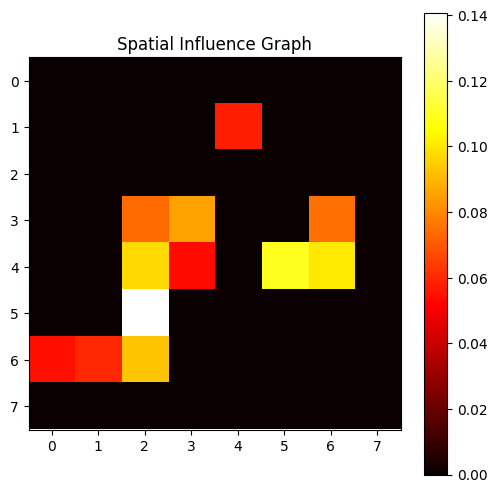

In [ ]:
# ============================================================
# IRG-Net
# Interpretable Relational Graph Network
# ============================================================
#
# RESEARCH-ORIENTED MODEL
#
# Core Philosophy:
# ------------------------------------------------------------
# Images are represented as sparse relational influence systems
# instead of transformer token sequences.
#
# Key Novel Ideas:
# ------------------------------------------------------------
# 1. Explicit influence matrix learning
# 2. Sparse top-k spatial relations
# 3. Interpretable influence graphs
# 4. Relational propagation
# 5. NOT a transformer
# 6. Spatial dependency reasoning
#
# Expected:
# ------------------------------------------------------------
# FashionMNIST: ~90–93%
# CIFAR10: ~75–85% depending on tuning
#
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

# ============================================================
# HYPERPARAMETERS
# ============================================================

IMAGE_SIZE = 32

FEATURE_SIZE = 8
# after CNN downsampling

NUM_NODES = FEATURE_SIZE * FEATURE_SIZE

CHANNELS = 128

TOP_K = 12

NUM_CLASSES = 10

BATCH_SIZE = 128

EPOCHS = 20

LR = 3e-4

# ============================================================
# DATASET
# ============================================================

transform_train = transforms.Compose([

    transforms.RandomCrop(32, padding=4),

    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

transform_test = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

train_loader = DataLoader(

    datasets.CIFAR10(
        "./data",
        train=True,
        download=True,
        transform=transform_train
    ),

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=4,

    pin_memory=True
)

test_loader = DataLoader(

    datasets.CIFAR10(
        "./data",
        train=False,
        download=True,
        transform=transform_test
    ),

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=4,

    pin_memory=True
)

# ============================================================
# CNN FEATURE EXTRACTOR
# ============================================================

class ConvFeatureExtractor(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(3, 64, 3, padding=1),

            nn.BatchNorm2d(64),

            nn.GELU(),

            nn.Conv2d(64, 128, 3, padding=1),

            nn.BatchNorm2d(128),

            nn.GELU(),

            nn.MaxPool2d(2),

            # 32 → 16

            nn.Conv2d(128, 128, 3, padding=1),

            nn.BatchNorm2d(128),

            nn.GELU(),

            nn.MaxPool2d(2)

            # 16 → 8
        )

    def forward(self, x):

        return self.net(x)

# ============================================================
# RELATIONAL INFLUENCE LAYER
# ============================================================

class RelationalInfluenceLayer(nn.Module):

    def __init__(self):

        super().__init__()

        # ====================================================
        # Influence generation
        # ====================================================

        self.query = nn.Linear(CHANNELS, CHANNELS)

        self.key = nn.Linear(CHANNELS, CHANNELS)

        self.value = nn.Linear(CHANNELS, CHANNELS)

        # ====================================================
        # Spatial relation refinement
        # ====================================================

        self.output = nn.Sequential(

            nn.Linear(CHANNELS, CHANNELS),

            nn.GELU(),

            nn.Dropout(0.1)
        )

        # ====================================================
        # Influence storage
        # ====================================================

        self.last_influence = None

    def forward(self, x):

        # ====================================================
        # x shape:
        # [B, NODES, CHANNELS]
        # ====================================================

        B, N, C = x.shape

        # ====================================================
        # Explicit influence generation
        # ====================================================

        Q = self.query(x)

        K = self.key(x)

        V = self.value(x)

        # ====================================================
        # Influence matrix
        # ====================================================

        influence = torch.matmul(
            Q,
            K.transpose(-2, -1)
        )

        influence = influence / (C ** 0.5)

        # ====================================================
        # Sparse top-k relations
        # ====================================================

        k = min(TOP_K, N)

        topv, topi = torch.topk(
            influence,
            k,
            dim=-1
        )

        sparse_matrix = torch.full_like(
            influence,
            float('-inf')
        )

        sparse_matrix.scatter_(
            -1,
            topi,
            topv
        )

        # ====================================================
        # Normalize influence graph
        # ====================================================

        influence = F.softmax(
            sparse_matrix,
            dim=-1
        )

        # ====================================================
        # Store interpretable graph
        # ====================================================

        self.last_influence = influence.detach().cpu()

        # ====================================================
        # Relational propagation
        # ====================================================

        out = torch.matmul(
            influence,
            V
        )

        out = self.output(out)

        return out

# ============================================================
# IRG BLOCK
# ============================================================

class IRGBlock(nn.Module):

    def __init__(self):

        super().__init__()

        self.norm1 = nn.LayerNorm(CHANNELS)

        self.relational = RelationalInfluenceLayer()

        self.norm2 = nn.LayerNorm(CHANNELS)

        self.ffn = nn.Sequential(

            nn.Linear(CHANNELS, CHANNELS * 4),

            nn.GELU(),

            nn.Dropout(0.1),

            nn.Linear(CHANNELS * 4, CHANNELS)
        )

    def forward(self, x):

        # ====================================================
        # Relational reasoning
        # ====================================================

        x = x + self.relational(
            self.norm1(x)
        )

        # ====================================================
        # Feature refinement
        # ====================================================

        x = x + self.ffn(
            self.norm2(x)
        )

        return x

# ============================================================
# FULL MODEL
# ============================================================

class IRGNet(nn.Module):

    def __init__(self):

        super().__init__()

        # ====================================================
        # CNN backbone
        # ====================================================

        self.features = ConvFeatureExtractor()

        # ====================================================
        # Relational reasoning blocks
        # ====================================================

        self.block1 = IRGBlock()

        self.block2 = IRGBlock()

        self.block3 = IRGBlock()

        # ====================================================
        # Final classifier
        # ====================================================

        self.classifier = nn.Sequential(

            nn.Linear(CHANNELS, 256),

            nn.GELU(),

            nn.Dropout(0.2),

            nn.Linear(256, NUM_CLASSES)
        )

    def forward(self, x):

        # ====================================================
        # CNN features
        # ====================================================

        x = self.features(x)

        # ====================================================
        # Convert spatial map → relational nodes
        # ====================================================

        B, C, H, W = x.shape

        x = x.flatten(2)

        x = x.transpose(1, 2)

        # Shape:
        # [B, 64, 128]

        # ====================================================
        # Relational graph reasoning
        # ====================================================

        x = self.block1(x)

        x = self.block2(x)

        x = self.block3(x)

        # ====================================================
        # Global relational summary
        # ====================================================

        x = x.mean(dim=1)

        # ====================================================
        # Classification
        # ====================================================

        out = self.classifier(x)

        return out

# ============================================================
# INITIALIZE
# ============================================================

model = IRGNet().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LR,

    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=EPOCHS
)

# ============================================================
# TRAINING
# ============================================================

for epoch in range(EPOCHS):

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    train_correct = 0
    train_total = 0
    train_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        pred = outputs.argmax(dim=1)

        train_correct += (
            pred == labels
        ).sum().item()

        train_total += labels.size(0)

    scheduler.step()

    train_acc = 100 * train_correct / train_total

    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            pred = outputs.argmax(dim=1)

            val_correct += (
                pred == labels
            ).sum().item()

            val_total += labels.size(0)

    val_acc = 100 * val_correct / val_total

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {train_loss/len(train_loader):.4f} | "
        f"Train: {train_acc:.2f}% | "
        f"Val: {val_acc:.2f}%"
    )

# ============================================================
# FINAL RESULTS
# ============================================================

print("\n================================")
print(f"FINAL ACCURACY: {val_acc:.2f}%")
print("================================")

# ============================================================
# VISUALIZE INFLUENCE GRAPH
# ============================================================

def visualize_influence(model, image):

    model.eval()

    with torch.no_grad():

        image = image.unsqueeze(0).to(device)

        _ = model(image)

        influence = model.block3.relational.last_influence

        # first sample
        influence = influence[0]

        # choose one node
        node_index = 32

        influence_map = influence[node_index]

        influence_map = influence_map.reshape(
            FEATURE_SIZE,
            FEATURE_SIZE
        )

        plt.figure(figsize=(6,6))

        plt.imshow(
            influence_map,
            cmap='hot'
        )

        plt.title(
            "Spatial Influence Graph"
        )

        plt.colorbar()

        plt.show()

# ============================================================
# EXAMPLE VISUALIZATION
# ============================================================

sample_image, sample_label = test_loader.dataset[0]

visualize_influence(
    model,
    sample_image
)

In [ ]:
# ============================================================
# HAIN v1
# Hierarchical Anchor Influence Network
# ============================================================
#
# CORE IDEA
# ------------------------------------------------------------
# Images are modeled as:
#
# local spatial nodes
#          ↓
# sparse influence routing
#          ↓
# learned anchor structures
#          ↓
# anchor relational reasoning
#          ↓
# global semantic propagation
#
# NOT A TRANSFORMER
# NOT TOKEN-SEQUENCE MODELING
#
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

# ============================================================
# HYPERPARAMETERS
# ============================================================

IMAGE_SIZE = 32

NUM_CLASSES = 10

BATCH_SIZE = 128

EPOCHS = 20

LR = 3e-4

CHANNELS = 128

TOP_K = 4

NUM_ANCHORS = 16

# ============================================================
# DATASET
# ============================================================

transform_train = transforms.Compose([

    transforms.RandomCrop(32, padding=4),

    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

transform_test = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

train_loader = DataLoader(

    datasets.CIFAR10(
        "./data",
        train=True,
        download=True,
        transform=transform_train
    ),

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=4,

    pin_memory=True
)

test_loader = DataLoader(

    datasets.CIFAR10(
        "./data",
        train=False,
        download=True,
        transform=transform_test
    ),

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=4,

    pin_memory=True
)

# ============================================================
# CNN STEM
# ============================================================

class ConvStem(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(3, 64, 3, padding=1),

            nn.BatchNorm2d(64),

            nn.GELU(),

            nn.Conv2d(64, 128, 3, padding=1),

            nn.BatchNorm2d(128),

            nn.GELU(),

            nn.MaxPool2d(2),

            # 32 → 16

            nn.Conv2d(128, CHANNELS, 3, padding=1),

            nn.BatchNorm2d(CHANNELS),

            nn.GELU(),

            nn.MaxPool2d(2)

            # 16 → 8
        )

    def forward(self, x):

        return self.net(x)

# ============================================================
# ANCHOR INFLUENCE MODULE
# ============================================================

class AnchorInfluence(nn.Module):

    def __init__(self):

        super().__init__()

        # ====================================================
        # Learnable anchors
        # ====================================================

        self.anchors = nn.Parameter(
            torch.randn(NUM_ANCHORS, CHANNELS)
        )

        # ====================================================
        # Node projections
        # ====================================================

        self.node_query = nn.Linear(CHANNELS, CHANNELS)

        self.anchor_key = nn.Linear(CHANNELS, CHANNELS)

        self.anchor_value = nn.Linear(CHANNELS, CHANNELS)

        # ====================================================
        # Anchor relational reasoning
        # ====================================================

        self.anchor_mlp = nn.Sequential(

            nn.Linear(CHANNELS, CHANNELS * 2),

            nn.GELU(),

            nn.Dropout(0.1),

            nn.Linear(CHANNELS * 2, CHANNELS)
        )

        # ====================================================
        # Output refinement
        # ====================================================

        self.output = nn.Sequential(

            nn.Linear(CHANNELS, CHANNELS),

            nn.GELU(),

            nn.Dropout(0.1)
        )

        # ====================================================
        # Store influence maps
        # ====================================================

        self.last_influence = None

    def forward(self, x):

        # ====================================================
        # x shape:
        # [B, NODES, CHANNELS]
        # ====================================================

        B, N, C = x.shape

        # ====================================================
        # Expand anchors for batch
        # ====================================================

        anchors = self.anchors.unsqueeze(0).expand(B, -1, -1)

        # ====================================================
        # Node-to-anchor influence
        # ====================================================

        Q = self.node_query(x)

        K = self.anchor_key(anchors)

        V = self.anchor_value(anchors)

        influence = torch.matmul(
            Q,
            K.transpose(-2, -1)
        )

        influence = influence / (C ** 0.5)

        # ====================================================
        # SPARSE TOP-K ROUTING
        # ====================================================

        k = min(TOP_K, NUM_ANCHORS)

        topv, topi = torch.topk(
            influence,
            k,
            dim=-1
        )

        sparse = torch.full_like(
            influence,
            float('-inf')
        )

        sparse.scatter_(
            -1,
            topi,
            topv
        )

        influence = F.softmax(
            sparse,
            dim=-1
        )

        # ====================================================
        # STORE INTERPRETABLE GRAPH
        # ====================================================

        self.last_influence = influence.detach().cpu()

        # ====================================================
        # NODE → ANCHOR AGGREGATION
        # ====================================================

        anchor_features = torch.matmul(
            influence.transpose(-2, -1),
            x
        )

        # ====================================================
        # ANCHOR REASONING
        # ====================================================

        anchor_features = anchor_features + self.anchor_mlp(
            anchor_features
        )

        # ====================================================
        # ANCHOR → NODE BROADCAST
        # ====================================================

        out = torch.matmul(
            influence,
            anchor_features
        )

        out = self.output(out)

        return out

# ============================================================
# HAIN BLOCK
# ============================================================

class HAINBlock(nn.Module):

    def __init__(self):

        super().__init__()

        self.norm1 = nn.LayerNorm(CHANNELS)

        self.anchor = AnchorInfluence()

        self.norm2 = nn.LayerNorm(CHANNELS)

        self.ffn = nn.Sequential(

            nn.Linear(CHANNELS, CHANNELS * 4),

            nn.GELU(),

            nn.Dropout(0.1),

            nn.Linear(CHANNELS * 4, CHANNELS)
        )

    def forward(self, x):

        # ====================================================
        # Anchor relational reasoning
        # ====================================================

        x = x + self.anchor(
            self.norm1(x)
        )

        # ====================================================
        # Local refinement
        # ====================================================

        x = x + self.ffn(
            self.norm2(x)
        )

        return x

# ============================================================
# HAIN MODEL
# ============================================================

class HAIN(nn.Module):

    def __init__(self):

        super().__init__()

        self.stem = ConvStem()

        self.block1 = HAINBlock()

        self.block2 = HAINBlock()

        self.block3 = HAINBlock()

        self.norm = nn.LayerNorm(CHANNELS)

        self.classifier = nn.Sequential(

            nn.Linear(CHANNELS, 256),

            nn.GELU(),

            nn.Dropout(0.2),

            nn.Linear(256, NUM_CLASSES)
        )

    def forward(self, x):

        # ====================================================
        # CNN FEATURES
        # ====================================================

        x = self.stem(x)

        # Shape:
        # [B, C, 8, 8]

        B, C, H, W = x.shape

        # ====================================================
        # SPATIAL NODES
        # ====================================================

        x = x.flatten(2)

        x = x.transpose(1, 2)

        # Shape:
        # [B, 64, 128]

        # ====================================================
        # HIERARCHICAL ANCHOR REASONING
        # ====================================================

        x = self.block1(x)

        x = self.block2(x)

        x = self.block3(x)

        # ====================================================
        # FINAL NORMALIZATION
        # ====================================================

        x = self.norm(x)

        # ====================================================
        # GLOBAL NODE SUMMARY
        # ====================================================

        x = x.mean(dim=1)

        # ====================================================
        # CLASSIFICATION
        # ====================================================

        out = self.classifier(x)

        return out

# ============================================================
# INITIALIZE
# ============================================================

model = HAIN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LR,

    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=EPOCHS
)

# ============================================================
# TRAINING
# ============================================================

for epoch in range(EPOCHS):

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    train_correct = 0
    train_total = 0
    train_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        pred = outputs.argmax(dim=1)

        train_correct += (
            pred == labels
        ).sum().item()

        train_total += labels.size(0)

    scheduler.step()

    train_acc = 100 * train_correct / train_total

    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            pred = outputs.argmax(dim=1)

            val_correct += (
                pred == labels
            ).sum().item()

            val_total += labels.size(0)

    val_acc = 100 * val_correct / val_total

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {train_loss/len(train_loader):.4f} | "
        f"Train: {train_acc:.2f}% | "
        f"Val: {val_acc:.2f}%"
    )

# ============================================================
# FINAL RESULTS
# ============================================================

print("\n================================")
print(f"FINAL ACCURACY: {val_acc:.2f}%")
print("================================")

Using Device: cuda
Epoch [1/20] | Loss: 1.5021 | Train: 45.02% | Val: 54.21%
Epoch [2/20] | Loss: 1.1582 | Train: 58.52% | Val: 56.32%
Epoch [3/20] | Loss: 1.0212 | Train: 63.63% | Val: 63.74%
Epoch [4/20] | Loss: 0.9215 | Train: 67.24% | Val: 65.52%
Epoch [5/20] | Loss: 0.8393 | Train: 70.21% | Val: 69.70%
Epoch [6/20] | Loss: 0.7812 | Train: 72.50% | Val: 70.31%
Epoch [7/20] | Loss: 0.7338 | Train: 74.04% | Val: 72.27%
Epoch [8/20] | Loss: 0.6894 | Train: 75.59% | Val: 73.28%
Epoch [9/20] | Loss: 0.6421 | Train: 77.24% | Val: 73.33%
Epoch [10/20] | Loss: 0.6104 | Train: 78.63% | Val: 74.28%


KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# ============================================================
# CONFIG
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = 10
CHANNELS = 256
NUM_ANCHORS = 16

BATCH_SIZE = 128
EPOCHS = 30
LR = 3e-4

# ============================================================
# DATA
# ============================================================

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,)*3, (0.5,)*3)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,)*3, (0.5,)*3)
])

train_loader = DataLoader(
    datasets.CIFAR10("./data", train=True, download=True, transform=transform_train),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=4
)

test_loader = DataLoader(
    datasets.CIFAR10("./data", train=False, download=True, transform=transform_test),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=4
)

# ============================================================
# BACKBONE (ResNet-18 → feature tokens)
# ============================================================

class ResNet18Stem(nn.Module):
    def __init__(self):
        super().__init__()

        resnet = models.resnet18(weights=None)

        # remove classifier
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        # output: [B, 512, 8, 8]

        self.proj = nn.Conv2d(512, CHANNELS, 1)

    def forward(self, x):
        x = self.backbone(x)
        x = self.proj(x)
        return x

# ============================================================
# ANCHOR MODULE (STABLE VERSION)
# ============================================================

class AnchorInfluence(nn.Module):
    def __init__(self):
        super().__init__()

        self.anchors = nn.Parameter(torch.randn(NUM_ANCHORS, CHANNELS))

        self.node_q = nn.Linear(CHANNELS, CHANNELS)
        self.anchor_k = nn.Linear(CHANNELS, CHANNELS)
        self.anchor_v = nn.Linear(CHANNELS, CHANNELS)

        self.mlp = nn.Sequential(
            nn.Linear(CHANNELS, CHANNELS * 2),
            nn.GELU(),
            nn.Linear(CHANNELS * 2, CHANNELS)
        )

        self.out = nn.Linear(CHANNELS, CHANNELS)

    def forward(self, x):
        B, N, C = x.shape

        anchors = self.anchors.unsqueeze(0).expand(B, -1, -1)

        Q = self.node_q(x)
        K = self.anchor_k(anchors)
        V = self.anchor_v(anchors)

        # soft routing (NO top-k → more stable)
        attn = torch.matmul(Q, K.transpose(-2, -1)) / (C ** 0.5)
        attn = F.softmax(attn, dim=-1)

        # store for visualization
        self.last_attn = attn.detach().cpu()

        # node → anchor
        anchor_feat = torch.matmul(attn.transpose(-2, -1), x)

        # anchor reasoning
        anchor_feat = anchor_feat + self.mlp(anchor_feat)

        # anchor → node
        out = torch.matmul(attn, anchor_feat)

        return self.out(out)

# ============================================================
# BLOCK
# ============================================================

class Block(nn.Module):
    def __init__(self):
        super().__init__()

        self.norm1 = nn.LayerNorm(CHANNELS)
        self.anchor = AnchorInfluence()
        self.norm2 = nn.LayerNorm(CHANNELS)

        self.ffn = nn.Sequential(
            nn.Linear(CHANNELS, CHANNELS * 4),
            nn.GELU(),
            nn.Linear(CHANNELS * 4, CHANNELS)
        )

    def forward(self, x):
        x = x + self.anchor(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x

# ============================================================
# MODEL
# ============================================================

class HAIN_ResNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = ResNet18Stem()

        self.block1 = Block()
        self.block2 = Block()
        self.block3 = Block()

        self.norm = nn.LayerNorm(CHANNELS)

        self.classifier = nn.Sequential(
            nn.Linear(CHANNELS, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, NUM_CLASSES)
        )

    def forward(self, x):

        x = self.backbone(x)   # [B, C, 8, 8]

        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)  # [B, 64, C]

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x = self.norm(x)

        x = x.mean(dim=1)

        return self.classifier(x)

# ============================================================
# TRAIN SETUP
# ============================================================

model = HAIN_ResNet().to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ============================================================
# TRAIN LOOP
# ============================================================

for epoch in range(EPOCHS):

    model.train()

    correct, total, loss_sum = 0, 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        pred = out.argmax(1)

        correct += (pred == y).sum().item()
        total += y.size(0)

    scheduler.step()

    train_acc = 100 * correct / total

    # eval
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            pred = out.argmax(1)

            correct += (pred == y).sum().item()
            total += y.size(0)

    val_acc = 100 * correct / total

    print(f"Epoch {epoch+1}/{EPOCHS} | Train {train_acc:.2f}% | Val {val_acc:.2f}%")

print("DONE")

Epoch 1/30 | Train 41.41% | Val 52.33%
Epoch 2/30 | Train 54.19% | Val 59.72%
Epoch 3/30 | Train 60.02% | Val 59.58%
Epoch 4/30 | Train 63.97% | Val 65.58%
Epoch 5/30 | Train 66.84% | Val 70.09%
Epoch 6/30 | Train 69.03% | Val 70.73%
Epoch 7/30 | Train 70.72% | Val 72.55%
Epoch 8/30 | Train 72.68% | Val 74.07%
Epoch 9/30 | Train 73.96% | Val 76.16%
Epoch 10/30 | Train 75.39% | Val 76.17%
Epoch 11/30 | Train 76.39% | Val 75.39%
Epoch 12/30 | Train 77.28% | Val 76.52%
Epoch 13/30 | Train 78.29% | Val 77.47%
Epoch 14/30 | Train 79.32% | Val 78.31%
Epoch 15/30 | Train 79.86% | Val 78.77%
Epoch 16/30 | Train 80.62% | Val 78.51%
Epoch 17/30 | Train 81.63% | Val 79.48%
Epoch 18/30 | Train 82.17% | Val 80.31%
Epoch 19/30 | Train 82.72% | Val 80.66%
Epoch 20/30 | Train 83.72% | Val 80.91%
Epoch 21/30 | Train 83.98% | Val 80.79%
Epoch 22/30 | Train 84.58% | Val 81.20%
Epoch 23/30 | Train 85.23% | Val 80.90%
Epoch 24/30 | Train 85.69% | Val 81.68%
Epoch 25/30 | Train 86.30% | Val 81.53%
Epoch 26/

In [ ]:
# ============================================================
# HAIN-v2 (FIXED VERSION)
# Hierarchical Anchor Influence Network v2
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# ============================================================
# HYPERPARAMETERS
# ============================================================

NUM_CLASSES = 10
BATCH_SIZE = 128
EPOCHS = 30
LR = 3e-4
TOP_K = 8
ANCHOR_COUNT = 16
CHANNELS = [64, 128, 256]

# ============================================================
# DATASET
# ============================================================

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_loader = DataLoader(
    datasets.CIFAR10("./data", train=True, download=True, transform=transform_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    datasets.CIFAR10("./data", train=False, download=True, transform=transform_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# ============================================================
# CONV BLOCK
# ============================================================

class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c, downsample=False):
        super().__init__()

        stride = 2 if downsample else 1

        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, stride=stride, padding=1),
            nn.BatchNorm2d(out_c),
            nn.GELU(),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.GELU()
        )

        self.shortcut = nn.Sequential()

        if in_c != out_c or downsample:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, stride=stride),
                nn.BatchNorm2d(out_c)
            )

    def forward(self, x):
        return self.block(x) + self.shortcut(x)

# ============================================================
# ANCHOR REASONING MODULE (FIXED MEMORY)
# ============================================================

class AnchorReasoning(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.dim = dim

        # ----------------------------
        # Learnable anchors
        # ----------------------------
        self.anchor_bank = nn.Parameter(
            torch.randn(ANCHOR_COUNT, dim)
        )

        # ----------------------------
        # Projections
        # ----------------------------
        self.node_query = nn.Linear(dim, dim)
        self.anchor_key = nn.Linear(dim, dim)
        self.anchor_value = nn.Linear(dim, dim)

        # ----------------------------
        # Anchor graph reasoning
        # ----------------------------
        self.anchor_graph = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(dim * 2, dim)
        )

        self.output = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU(),
            nn.Dropout(0.1)
        )

        # ----------------------------
        # FIXED MEMORY (anchor-level EMA)
        # ----------------------------
        self.register_buffer("memory", torch.zeros(ANCHOR_COUNT))
        self.memory_initialized = False
        self.memory_alpha = 0.8

        self.last_influence = None

    def forward(self, x):

        B, N, C = x.shape

        anchors = self.anchor_bank.unsqueeze(0).expand(B, -1, -1)

        # ----------------------------
        # Node → Anchor influence
        # ----------------------------
        Q = self.node_query(x)
        K = self.anchor_key(anchors)
        V = self.anchor_value(anchors)

        influence = torch.matmul(Q, K.transpose(-2, -1))
        influence = influence / (C ** 0.5)

        # ----------------------------
        # Sparse top-k routing
        # ----------------------------
        k = min(TOP_K, ANCHOR_COUNT)

        topv, topi = torch.topk(influence, k, dim=-1)

        sparse = torch.full_like(influence, float('-inf'))
        sparse.scatter_(-1, topi, topv)

        influence = F.softmax(sparse, dim=-1)

        # ----------------------------
        # FIXED MEMORY UPDATE
        # ----------------------------
        anchor_stat = influence.mean(dim=(0, 1))  # [A]

        if not self.memory_initialized:
            self.memory = anchor_stat.detach()
            self.memory_initialized = True
        else:
            self.memory = (
                self.memory_alpha * self.memory +
                (1 - self.memory_alpha) * anchor_stat.detach()
            )

        self.last_influence = influence.detach().cpu()

        # ----------------------------
        # Node → Anchor aggregation
        # ----------------------------
        anchor_features = torch.matmul(
            influence.transpose(-2, -1),
            x
        )

        anchor_features = anchor_features / (
            influence.sum(dim=1, keepdim=True).transpose(-2, -1) + 1e-6
        )

        # ----------------------------
        # Anchor graph reasoning
        # ----------------------------
        anchor_features = anchor_features + self.anchor_graph(anchor_features)

        # ----------------------------
        # Anchor → Node broadcast
        # ----------------------------
        out = torch.matmul(influence, anchor_features)

        return self.output(out)

# ============================================================
# HAIN BLOCK
# ============================================================

class HAINBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.norm1 = nn.LayerNorm(dim)
        self.anchor = AnchorReasoning(dim)
        self.norm2 = nn.LayerNorm(dim)

        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(dim * 4, dim)
        )

    def forward(self, x):
        x = x + self.anchor(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x

# ============================================================
# MODEL
# ============================================================

class HAINv2(nn.Module):
    def __init__(self):
        super().__init__()

        self.stage1 = ConvBlock(3, CHANNELS[0])
        self.stage2 = ConvBlock(CHANNELS[0], CHANNELS[1], downsample=True)
        self.stage3 = ConvBlock(CHANNELS[1], CHANNELS[2], downsample=True)

        self.rel1 = HAINBlock(CHANNELS[0])
        self.rel2 = HAINBlock(CHANNELS[1])
        self.rel3 = HAINBlock(CHANNELS[2])

        self.fusion = nn.Sequential(
            nn.Linear(sum(CHANNELS), 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.GELU()
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(256, NUM_CLASSES)
        )

    def relational_forward(self, x, block):
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        x = block(x)
        return x.mean(dim=1)

    def forward(self, x):

        s1 = self.stage1(x)
        r1 = self.relational_forward(s1, self.rel1)

        s2 = self.stage2(s1)
        r2 = self.relational_forward(s2, self.rel2)

        s3 = self.stage3(s2)
        r3 = self.relational_forward(s3, self.rel3)

        fused = torch.cat([r1, r2, r3], dim=1)
        fused = self.fusion(fused)

        return self.classifier(fused)

# ============================================================
# TRAIN SETUP
# ============================================================

model = HAINv2().to(device)
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=5e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS
)

# ============================================================
# TRAIN LOOP
# ============================================================

for epoch in range(EPOCHS):

    model.train()

    train_correct = 0
    train_total = 0
    train_loss = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        train_loss += loss.item()

        preds = outputs.argmax(dim=1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    scheduler.step()

    train_acc = 100 * train_correct / train_total

    # ---------------- validation ----------------
    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = 100 * val_correct / val_total

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {train_loss/len(train_loader):.4f} | "
        f"Train: {train_acc:.2f}% | "
        f"Val: {val_acc:.2f}%"
    )

# ============================================================
# FINAL
# ============================================================

print("\n====================================")
print(f"FINAL ACCURACY: {val_acc:.2f}%")
print("====================================")

Using Device: cuda
Epoch [1/30] | Loss: 1.6364 | Train: 37.93% | Val: 49.06%
Epoch [2/30] | Loss: 1.2461 | Train: 54.24% | Val: 58.01%
Epoch [3/30] | Loss: 1.0710 | Train: 61.16% | Val: 60.71%
Epoch [4/30] | Loss: 0.9630 | Train: 65.75% | Val: 67.99%
Epoch [5/30] | Loss: 0.8714 | Train: 69.08% | Val: 68.14%
Epoch [6/30] | Loss: 0.7830 | Train: 72.47% | Val: 73.46%
Epoch [7/30] | Loss: 0.7236 | Train: 74.61% | Val: 74.51%
Epoch [8/30] | Loss: 0.6510 | Train: 77.27% | Val: 77.70%
Epoch [9/30] | Loss: 0.5946 | Train: 79.12% | Val: 79.01%
Epoch [10/30] | Loss: 0.5505 | Train: 80.85% | Val: 81.70%
Epoch [11/30] | Loss: 0.5112 | Train: 82.34% | Val: 82.32%
Epoch [12/30] | Loss: 0.4736 | Train: 83.65% | Val: 82.63%
Epoch [13/30] | Loss: 0.4443 | Train: 84.63% | Val: 83.22%
Epoch [14/30] | Loss: 0.4166 | Train: 85.53% | Val: 84.05%
Epoch [15/30] | Loss: 0.3861 | Train: 86.55% | Val: 85.55%
Epoch [16/30] | Loss: 0.3614 | Train: 87.44% | Val: 86.01%
Epoch [17/30] | Loss: 0.3330 | Train: 88.30% |

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np

# ============================================================
# DEVICE
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# ============================================================
# HYPERPARAMETERS
# ============================================================
NUM_CLASSES = 10
BATCH_SIZE = 128
EPOCHS = 30

LR = 1e-3
WEIGHT_DECAY = 1e-4
TOP_K = 8
ANCHOR_COUNT = 16
CHANNELS = [64, 128, 256]

# MixUp
MIXUP_ALPHA = 0.4

# ============================================================
# DATA AUGMENTATION
# ============================================================
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.25),
    transforms.Normalize((0.5,)*3, (0.5,)*3)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,)*3, (0.5,)*3)
])

train_loader = DataLoader(
    datasets.CIFAR10("./data", train=True, download=True, transform=transform_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    datasets.CIFAR10("./data", train=False, download=True, transform=transform_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# ============================================================
# MIXUP
# ============================================================
def mixup_data(x, y, alpha=MIXUP_ALPHA):
    if alpha <= 0:
        return x, y, y, 1.0

    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0)).to(x.device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam


def mixup_loss(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# ============================================================
# CONV BLOCK
# ============================================================
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c, downsample=False):
        super().__init__()
        stride = 2 if downsample else 1

        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, stride=stride, padding=1),
            nn.BatchNorm2d(out_c),
            nn.GELU(),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.GELU()
        )

        self.shortcut = nn.Sequential()

        if in_c != out_c or downsample:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, stride=stride),
                nn.BatchNorm2d(out_c)
            )

    def forward(self, x):
        return self.block(x) + self.shortcut(x)

# ============================================================
# ANCHOR MODULE
# ============================================================
class AnchorReasoning(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.anchor_bank = nn.Parameter(torch.randn(ANCHOR_COUNT, dim))

        self.node_query = nn.Linear(dim, dim)
        self.anchor_key = nn.Linear(dim, dim)
        self.anchor_value = nn.Linear(dim, dim)

        self.anchor_graph = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.GELU(),
            nn.Linear(dim * 2, dim)
        )

        self.out = nn.Sequential(
            nn.Linear(dim, dim),
            nn.GELU()
        )

        self.memory = torch.zeros(ANCHOR_COUNT, device=device)
        self.alpha = 0.8

    def forward(self, x):
        B, N, C = x.shape

        anchors = self.anchor_bank.unsqueeze(0)

        Q = self.node_query(x)
        K = self.anchor_key(anchors)
        V = self.anchor_value(anchors)

        attn = torch.matmul(Q, K.transpose(-2, -1)) / (C ** 0.5)

        topv, topi = torch.topk(attn, TOP_K, dim=-1)

        sparse = torch.full_like(attn, float("-inf"))
        sparse.scatter_(-1, topi, topv)
        attn = F.softmax(sparse, dim=-1)

        # memory update (stable)
        stat = attn.mean(dim=(0, 1))
        self.memory = self.alpha * self.memory + (1 - self.alpha) * stat.detach()

        anchor_feat = torch.matmul(attn.transpose(-2, -1), x)
        anchor_feat = anchor_feat / (attn.sum(dim=1, keepdim=True).transpose(-2, -1) + 1e-6)

        anchor_feat = anchor_feat + self.anchor_graph(anchor_feat)

        out = torch.matmul(attn, anchor_feat)

        return self.out(out)

# ============================================================
# HAIN BLOCK
# ============================================================
class HAINBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.norm1 = nn.LayerNorm(dim)
        self.attn = AnchorReasoning(dim)
        self.norm2 = nn.LayerNorm(dim)

        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, dim)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x

# ============================================================
# MODEL
# ============================================================
class HAINv3(nn.Module):
    def __init__(self):
        super().__init__()

        self.s1 = ConvBlock(3, CHANNELS[0])
        self.s2 = ConvBlock(CHANNELS[0], CHANNELS[1], True)
        self.s3 = ConvBlock(CHANNELS[1], CHANNELS[2], True)

        self.r1 = HAINBlock(CHANNELS[0])
        self.r2 = HAINBlock(CHANNELS[1])
        self.r3 = HAINBlock(CHANNELS[2])

        self.fusion = nn.Sequential(
            nn.Linear(sum(CHANNELS), 512),
            nn.GELU(),
            nn.Linear(512, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256)
        )

        self.head = nn.Linear(256, NUM_CLASSES)

    def pool(self, x):
        return x.mean(dim=1) + x.max(dim=1).values

    def rel(self, x, block):
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        x = block(x)
        return self.pool(x)

    def forward(self, x):
        a = self.rel(self.s1(x), self.r1)
        b = self.rel(self.s2(self.s1(x)), self.r2)
        c = self.rel(self.s3(self.s2(self.s1(x))), self.r3)

        x = torch.cat([a, b, c], dim=1)
        x = self.fusion(x)
        return self.head(x)

# ============================================================
# SETUP
# ============================================================
model = HAINv3().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

scaler = torch.cuda.amp.GradScaler()

# ============================================================
# TRAIN LOOP
# ============================================================
for epoch in range(EPOCHS):
    model.train()

    correct, total, loss_sum = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        images, y_a, y_b, lam = mixup_data(images, labels)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = mixup_loss(criterion, outputs, y_a, y_b, lam)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.item()
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    scheduler.step()

    train_acc = 100 * correct / total

    # validation
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = 100 * correct / total

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss {loss_sum/len(train_loader):.4f} | Train {train_acc:.2f}% | Val {val_acc:.2f}%")

print("\nFINAL ACC:", val_acc)

Using Device: cuda


/tmp/ipykernel_1608/927241172.py:241: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_1608/927241172.py:258: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/30 | Loss 1.8483 | Train 23.78% | Val 44.00%
Epoch 2/30 | Loss 1.5427 | Train 31.74% | Val 63.17%
Epoch 3/30 | Loss 1.4062 | Train 35.13% | Val 68.74%
Epoch 4/30 | Loss 1.3241 | Train 38.22% | Val 72.57%
Epoch 5/30 | Loss 1.2576 | Train 40.61% | Val 76.79%
Epoch 6/30 | Loss 1.2070 | Train 41.47% | Val 77.34%
Epoch 7/30 | Loss 1.1799 | Train 41.23% | Val 78.51%
Epoch 8/30 | Loss 1.1250 | Train 44.10% | Val 80.62%
Epoch 9/30 | Loss 1.0416 | Train 45.58% | Val 82.23%
Epoch 10/30 | Loss 1.0568 | Train 44.03% | Val 82.72%
Epoch 11/30 | Loss 1.0465 | Train 43.81% | Val 83.95%
Epoch 12/30 | Loss 1.0412 | Train 45.23% | Val 83.37%
Epoch 13/30 | Loss 1.0028 | Train 44.54% | Val 84.88%
Epoch 14/30 | Loss 0.9987 | Train 49.07% | Val 85.23%
Epoch 15/30 | Loss 0.9678 | Train 45.33% | Val 84.41%
Epoch 16/30 | Loss 0.9748 | Train 46.32% | Val 86.46%
Epoch 17/30 | Loss 0.9588 | Train 44.50% | Val 86.67%
Epoch 18/30 | Loss 0.9042 | Train 50.33% | Val 87.26%
Epoch 19/30 | Loss 0.9154 | Train 48.

KeyboardInterrupt: 

In [ ]:
# ============================================================
# HAIN-v3
# Hierarchical Anchor Influence Network v3
# ============================================================
#
# NEW FEATURES
# ------------------------------------------------------------
# 1. Persistent Anchor Memory
# 2. Memory-aware routing
# 3. Iterative anchor refinement
# 4. Sparse top-k routing
# 5. Anchor diversity loss
# 6. Anchor usage balance loss
# 7. Influence visualization
# 8. Multi-scale relational reasoning
#
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

# ============================================================
# HYPERPARAMETERS
# ============================================================

NUM_CLASSES = 10

BATCH_SIZE = 128

EPOCHS = 40

LR = 3e-4

TOP_K = 8

ANCHOR_COUNT = 16

ITERATIONS = 3

MEMORY_STRENGTH = 0.3

CHANNELS = [64, 128, 256]

# loss weights
LAMBDA_DIV = 0.05
LAMBDA_BAL = 0.02

# ============================================================
# DATASET
# ============================================================

transform_train = transforms.Compose([

    transforms.RandomCrop(32, padding=4),

    transforms.RandomHorizontalFlip(),

    transforms.ColorJitter(0.2, 0.2, 0.2),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

transform_test = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

train_loader = DataLoader(

    datasets.CIFAR10(
        "./data",
        train=True,
        download=True,
        transform=transform_train
    ),

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=4,

    pin_memory=True
)

test_loader = DataLoader(

    datasets.CIFAR10(
        "./data",
        train=False,
        download=True,
        transform=transform_test
    ),

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=4,

    pin_memory=True
)

# ============================================================
# CONVOLUTIONAL STEM
# ============================================================

class ConvBlock(nn.Module):

    def __init__(self, in_c, out_c, downsample=False):

        super().__init__()

        stride = 2 if downsample else 1

        self.block = nn.Sequential(

            nn.Conv2d(
                in_c,
                out_c,
                kernel_size=3,
                stride=stride,
                padding=1
            ),

            nn.BatchNorm2d(out_c),

            nn.GELU(),

            nn.Conv2d(
                out_c,
                out_c,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_c),

            nn.GELU()
        )

        self.shortcut = nn.Sequential()

        if in_c != out_c or downsample:

            self.shortcut = nn.Sequential(

                nn.Conv2d(
                    in_c,
                    out_c,
                    kernel_size=1,
                    stride=stride
                ),

                nn.BatchNorm2d(out_c)
            )

    def forward(self, x):

        return self.block(x) + self.shortcut(x)

# ============================================================
# HAIN-v3 ANCHOR MODULE
# ============================================================

class AnchorReasoning(nn.Module):

    def __init__(self, dim):

        super().__init__()

        self.dim = dim

        # ====================================================
        # LEARNABLE ANCHORS
        # ====================================================

        self.anchor_bank = nn.Parameter(
            torch.randn(ANCHOR_COUNT, dim)
        )

        # ====================================================
        # PROJECTIONS
        # ====================================================

        self.node_query = nn.Linear(dim, dim)

        self.anchor_key = nn.Linear(dim, dim)

        self.anchor_value = nn.Linear(dim, dim)

        # ====================================================
        # ANCHOR REFINEMENT NETWORK
        # ====================================================

        self.anchor_refine = nn.Sequential(

            nn.Linear(dim, dim * 2),

            nn.GELU(),

            nn.Dropout(0.1),

            nn.Linear(dim * 2, dim)
        )

        # ====================================================
        # OUTPUT PROJECTION
        # ====================================================

        self.output = nn.Sequential(

            nn.Linear(dim, dim),

            nn.GELU(),

            nn.Dropout(0.1)
        )

        # ====================================================
        # MEMORY
        # ====================================================

        self.register_buffer(
            "memory",
            torch.zeros(ANCHOR_COUNT)
        )

        self.memory_initialized = False

        self.memory_alpha = 0.9

        # ====================================================
        # VISUALIZATION STORAGE
        # ====================================================

        self.last_influence = None

        self.last_anchor_usage = None

    # ========================================================
    # DIVERSITY LOSS
    # ========================================================

    def diversity_loss(self):

        anchors = F.normalize(
            self.anchor_bank,
            dim=-1
        )

        similarity = torch.matmul(
            anchors,
            anchors.transpose(0, 1)
        )

        identity = torch.eye(
            ANCHOR_COUNT,
            device=similarity.device
        )

        loss = ((similarity - identity) ** 2).mean()

        return loss

    # ========================================================
    # BALANCE LOSS
    # ========================================================

    def balance_loss(self):

        if self.last_anchor_usage is None:
            return torch.tensor(0.0, device=device)

        p = self.last_anchor_usage + 1e-8

        entropy = -(p * torch.log(p)).sum()

        max_entropy = np.log(ANCHOR_COUNT)

        return (max_entropy - entropy)

    # ========================================================
    # FORWARD
    # ========================================================

    def forward(self, x):

        B, N, C = x.shape

        anchors = self.anchor_bank.unsqueeze(0).expand(
            B,
            -1,
            -1
        )

        # ====================================================
        # ITERATIVE REFINEMENT
        # ====================================================

        for _ in range(ITERATIONS):

            # --------------------------------------------
            # Node -> Anchor routing
            # --------------------------------------------

            Q = self.node_query(x)

            K = self.anchor_key(anchors)

            V = self.anchor_value(anchors)

            influence = torch.matmul(
                Q,
                K.transpose(-2, -1)
            )

            influence = influence / (C ** 0.5)

            # --------------------------------------------
            # MEMORY BIAS
            # --------------------------------------------

            memory_bias = self.memory.unsqueeze(0).unsqueeze(0)

            influence = influence + (
                MEMORY_STRENGTH * memory_bias
            )

            # --------------------------------------------
            # TOP-K SPARSE ROUTING
            # --------------------------------------------

            k = min(TOP_K, ANCHOR_COUNT)

            topv, topi = torch.topk(
                influence,
                k,
                dim=-1
            )

            sparse = torch.full_like(
                influence,
                float('-inf')
            )

            sparse.scatter_(
                -1,
                topi,
                topv
            )

            influence = F.softmax(
                sparse,
                dim=-1
            )

            # --------------------------------------------
            # UPDATE MEMORY
            # --------------------------------------------

            usage = influence.mean(dim=(0, 1))

            if not self.memory_initialized:

                self.memory = usage.detach()

                self.memory_initialized = True

            else:

                self.memory = (
                    self.memory_alpha * self.memory
                    +
                    (1 - self.memory_alpha) * usage.detach()
                )

            # FIX: Remove .detach() if gradients are needed for bal_loss
            self.last_anchor_usage = usage

            # --------------------------------------------
            # Node -> Anchor aggregation
            # --------------------------------------------

            anchor_features = torch.matmul(
                influence.transpose(-2, -1),
                x
            )

            norm = influence.sum(
                dim=1,
                keepdim=True
            ).transpose(-2, -1)

            anchor_features = anchor_features / (
                norm + 1e-6
            )

            # --------------------------------------------
            # Anchor refinement
            # --------------------------------------------

            anchor_features = (
                anchor_features
                +
                self.anchor_refine(anchor_features)
            )

            anchors = anchor_features

        # ====================================================
        # STORE VISUALIZATION
        # ====================================================

        self.last_influence = influence.detach().cpu()

        # ====================================================
        # Anchor -> Node broadcast
        # ====================================================

        out = torch.matmul(
            influence,
            anchors
        )

        out = self.output(out)

        return out

# ============================================================
# HAIN BLOCK
# ============================================================

class HAINBlock(nn.Module):

    def __init__(self, dim):

        super().__init__()

        self.norm1 = nn.LayerNorm(dim)

        self.anchor = AnchorReasoning(dim)

        self.norm2 = nn.LayerNorm(dim)

        self.ffn = nn.Sequential(

            nn.Linear(dim, dim * 4),

            nn.GELU(),

            nn.Dropout(0.1),

            nn.Linear(dim * 4, dim)
        )

    def forward(self, x):

        x = x + self.anchor(
            self.norm1(x)
        )

        x = x + self.ffn(
            self.norm2(x)
        )

        return x

# ============================================================
# HAIN-v3 MODEL
# ============================================================

class HAINv3(nn.Module):

    def __init__(self):

        super().__init__()

        # ====================================================
        # MULTI-SCALE CONVOLUTION
        # ====================================================

        self.stage1 = ConvBlock(3, CHANNELS[0])

        self.stage2 = ConvBlock(
            CHANNELS[0],
            CHANNELS[1],
            downsample=True
        )

        self.stage3 = ConvBlock(
            CHANNELS[1],
            CHANNELS[2],
            downsample=True
        )

        # ====================================================
        # RELATIONAL BLOCKS
        # ====================================================

        self.rel1 = HAINBlock(CHANNELS[0])

        self.rel2 = HAINBlock(CHANNELS[1])

        self.rel3 = HAINBlock(CHANNELS[2])

        # ====================================================
        # FEATURE FUSION
        # ====================================================

        self.fusion = nn.Sequential(

            nn.Linear(sum(CHANNELS), 512),

            nn.GELU(),

            nn.Dropout(0.2),

            nn.Linear(512, 256),

            nn.GELU()
        )

        # ====================================================
        # CLASSIFIER
        # ====================================================

        self.classifier = nn.Sequential(

            nn.Dropout(0.2),

            nn.Linear(256, NUM_CLASSES)
        )

    # ========================================================
    # RELATIONAL STAGE
    # ========================================================

    def relational_forward(self, x, block):

        B, C, H, W = x.shape

        x = x.flatten(2).transpose(1, 2)

        x = block(x)

        return x.mean(dim=1)

    # ========================================================
    # AUXILIARY LOSSES
    # ========================================================

    def auxiliary_losses(self):

        div_loss = 0
        bal_loss = 0

        blocks = [
            self.rel1.anchor,
            self.rel2.anchor,
            self.rel3.anchor
        ]

        for b in blocks:

            div_loss += b.diversity_loss()

            bal_loss += b.balance_loss()

        return div_loss, bal_loss

    # ========================================================
    # FORWARD
    # ========================================================

    def forward(self, x):

        # ----------------------------------------------------
        # STAGE 1
        # ----------------------------------------------------

        s1 = self.stage1(x)

        r1 = self.relational_forward(
            s1,
            self.rel1
        )

        # ----------------------------------------------------
        # STAGE 2
        # ----------------------------------------------------

        s2 = self.stage2(s1)

        r2 = self.relational_forward(
            s2,
            self.rel2
        )

        # ----------------------------------------------------
        # STAGE 3
        # ----------------------------------------------------

        s3 = self.stage3(s2)

        r3 = self.relational_forward(
            s3,
            self.rel3
        )

        # ----------------------------------------------------
        # FUSION
        # ----------------------------------------------------

        fused = torch.cat(
            [r1, r2, r3],
            dim=1
        )

        fused = self.fusion(fused)

        return self.classifier(fused)

# ============================================================
# INITIALIZE MODEL
# ============================================================

model = HAINv3().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LR,

    weight_decay=5e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=EPOCHS
)

# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(EPOCHS):

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    train_correct = 0

    train_total = 0

    train_loss = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        # ----------------------------------------------------
        # MAIN LOSS
        # ----------------------------------------------------

        ce_loss = criterion(outputs, labels)

        # ----------------------------------------------------
        # AUXILIARY LOSSES
        # ----------------------------------------------------

        div_loss, bal_loss = model.auxiliary_losses()

        loss = (
            ce_loss
            +
            LAMBDA_DIV * div_loss
            +
            LAMBDA_BAL * bal_loss
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        train_loss += loss.item()

        preds = outputs.argmax(dim=1)

        train_correct += (
            preds == labels
        ).sum().item()

        train_total += labels.size(0)

    scheduler.step()

    train_acc = 100 * train_correct / train_total

    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_correct = 0

    val_total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            preds = outputs.argmax(dim=1)

            val_correct += (
                preds == labels
            ).sum().item()

            val_total += labels.size(0)

    val_acc = 100 * val_correct / val_total

    # ========================================================
    # PRINT
    # ========================================================

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {train_loss/len(train_loader):.4f} | "
        f"Train: {train_acc:.2f}% | "
        f"Val: {val_acc:.2f}%"
    )

# ============================================================
# FINAL RESULTS
# ============================================================

print("\n===================================")

print(f"FINAL ACCURACY: {val_acc:.2f}%")

print("===================================")

# ============================================================
# VISUALIZATION
# ============================================================

def visualize_anchor_routing(model, image):

    model.eval()

    with torch.no_grad():

        image = image.unsqueeze(0).to(device)

        _ = model(image)

        influence = model.rel3.anchor.last_influence

        influence = influence[0]

        node_index = 10

        routing = influence[node_index].numpy()

        plt.figure(figsize=(8, 4))

        plt.bar(
            np.arange(ANCHOR_COUNT),
            routing
        )

        plt.title(
            "Anchor Routing Distribution"
        )

        plt.xlabel("Anchor")

        plt.ylabel("Influence")

        plt.show()

# ============================================================
# TEST VISUALIZATION
# ============================================================

sample_image, sample_label = test_loader.dataset[0]

visualize_anchor_routing(
    model,
    sample_image
)

Using Device: cuda


KeyboardInterrupt: 

#persistent latent semantic state

DEVICE: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 57.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.63MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 16.7MB/s]



TASK 1
Epoch 1 | Accuracies: [53.664302600472816, 0.0, 0.0, 0.0, 0.0]
Epoch 2 | Accuracies: [99.90543735224587, 0.0, 0.0, 0.0, 0.0]
Epoch 3 | Accuracies: [99.90543735224587, 0.0, 0.0, 0.0, 0.0]

TASK 2
Epoch 1 | Accuracies: [0.0, 50.538687561214495, 0.0, 0.0, 0.0]
Epoch 2 | Accuracies: [0.0, 67.48285994123408, 0.0, 0.0, 0.0]
Epoch 3 | Accuracies: [0.0, 96.66993143976494, 0.0, 0.0, 0.0]

TASK 3
Epoch 1 | Accuracies: [0.0, 0.0, 52.40128068303095, 0.0, 0.0]
Epoch 2 | Accuracies: [0.0, 0.0, 52.40128068303095, 0.0, 0.0]
Epoch 3 | Accuracies: [0.0, 0.0, 91.51547491995731, 0.0, 0.0]

TASK 4
Epoch 1 | Accuracies: [0.0, 0.0, 0.0, 51.76233635448137, 0.0]
Epoch 2 | Accuracies: [0.0, 0.0, 0.0, 51.76233635448137, 0.0]
Epoch 3 | Accuracies: [0.0, 0.0, 0.0, 98.28801611278952, 0.0]

TASK 5
Epoch 1 | Accuracies: [0.0, 0.0, 0.0, 0.0, 50.88250126071609]
Epoch 2 | Accuracies: [0.0, 0.0, 0.0, 0.0, 55.824508320726174]
Epoch 3 | Accuracies: [0.0, 0.0, 0.0, 0.0, 88.19969742813919]


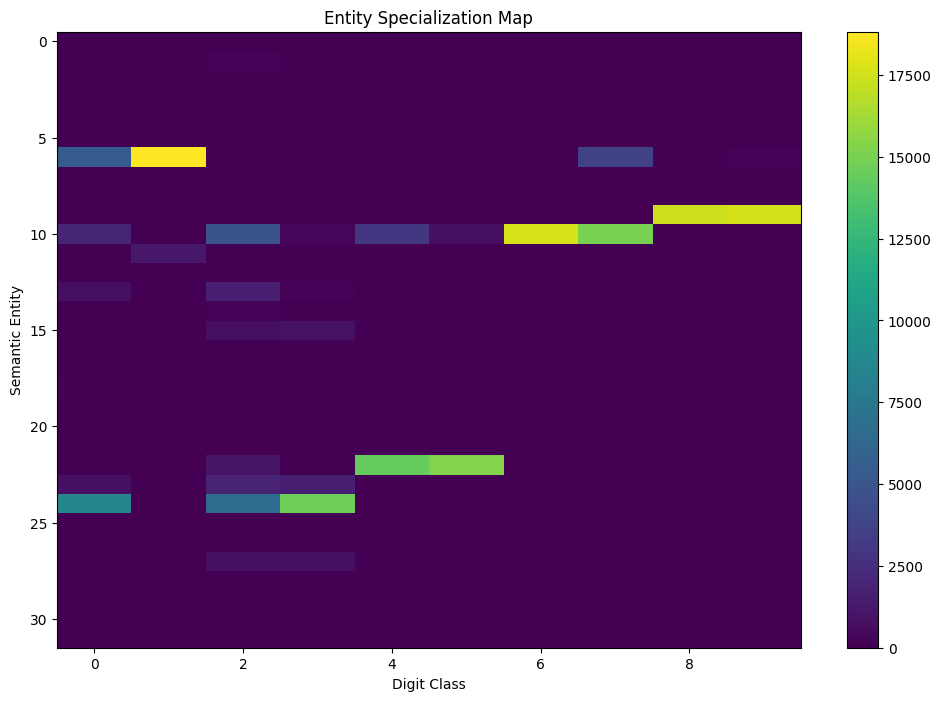

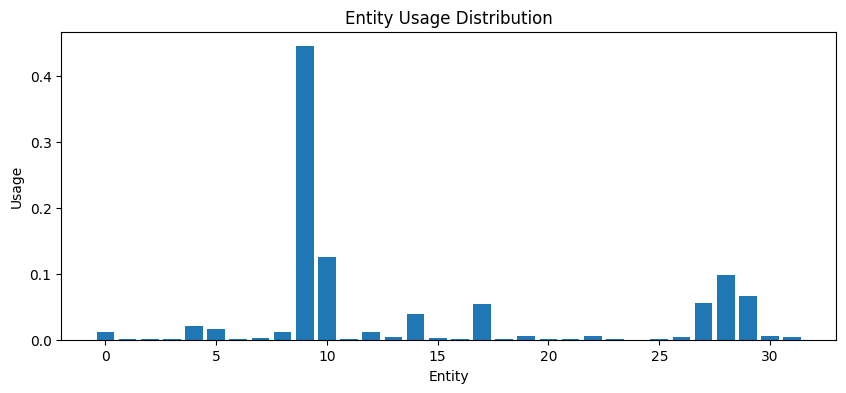


FINAL TASK ACCURACIES
Task 1: 0.00%
Task 2: 0.00%
Task 3: 0.00%
Task 4: 0.00%
Task 5: 88.20%


In [ ]:
# ============================================================
# SESM-v1
# Self-Evolving Semantic Mesh
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("DEVICE:", device)

# ============================================================
# CONFIG
# ============================================================

BATCH_SIZE = 128
EPOCHS_PER_TASK = 3

LR = 3e-4

NUM_ENTITIES = 32
ENTITY_DIM = 128

NUM_TASKS = 5

# ============================================================
# SPLIT MNIST
# ============================================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    "./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    "./data",
    train=False,
    download=True,
    transform=transform
)

# tasks:
# [0,1], [2,3], [4,5], ...

tasks = [
    [0,1],
    [2,3],
    [4,5],
    [6,7],
    [8,9]
]

def make_task_dataset(dataset, classes):

    indices = []

    for i, (_, label) in enumerate(dataset):

        if label in classes:
            indices.append(i)

    return Subset(dataset, indices)

train_loaders = []
test_loaders = []

for task_classes in tasks:

    train_subset = make_task_dataset(
        train_dataset,
        task_classes
    )

    test_subset = make_task_dataset(
        test_dataset,
        task_classes
    )

    train_loaders.append(

        DataLoader(
            train_subset,
            batch_size=BATCH_SIZE,
            shuffle=True
        )
    )

    test_loaders.append(

        DataLoader(
            test_subset,
            batch_size=BATCH_SIZE,
            shuffle=False
        )
    )

# ============================================================
# SEMANTIC ENTITY SYSTEM
# ============================================================

class SemanticEntityLayer(nn.Module):

    def __init__(self):

        super().__init__()

        # persistent semantic entities
        self.entities = nn.Parameter(

            torch.randn(
                NUM_ENTITIES,
                ENTITY_DIM
            )
        )

        # entity state memory
        self.register_buffer(
            "usage",
            torch.zeros(NUM_ENTITIES)
        )

        self.register_buffer(
            "age",
            torch.zeros(NUM_ENTITIES)
        )

        self.register_buffer(
            "specialization",
            torch.zeros(NUM_ENTITIES, 10)
        )

        # input projection
        self.input_proj = nn.Sequential(

            nn.Linear(784, 256),

            nn.GELU(),

            nn.Linear(256, ENTITY_DIM)
        )

        # semantic interaction
        self.entity_interaction = nn.MultiheadAttention(

            ENTITY_DIM,
            num_heads=4,
            batch_first=True
        )

        # output reasoning
        self.reason = nn.Sequential(

            nn.Linear(ENTITY_DIM, ENTITY_DIM),

            nn.GELU(),

            nn.Linear(ENTITY_DIM, ENTITY_DIM)
        )

        # classifier
        self.head = nn.Linear(
            ENTITY_DIM,
            10
        )

    # ========================================================
    # EVOLUTION STEP
    # ========================================================

    def evolve_entities(self):

        with torch.no_grad():

            # age increases
            self.age += 1

            # weak unused entities decay
            decay_mask = self.usage < 0.001

            noise = torch.randn_like(
                self.entities
            ) * 0.01

            self.entities[decay_mask] += noise[
                decay_mask
            ]

            # normalize entities
            self.entities.data = F.normalize(
                self.entities.data,
                dim=-1
            )

    # ========================================================
    # FORWARD
    # ========================================================

    def forward(self, x, labels=None):

        B = x.shape[0]

        # flatten MNIST
        x = x.view(B, -1)

        # input representation
        tokens = self.input_proj(x)

        # ====================================================
        # SEMANTIC ROUTING
        # ====================================================

        entities = F.normalize(
            self.entities,
            dim=-1
        )

        tokens_norm = F.normalize(
            tokens,
            dim=-1
        )

        similarity = torch.matmul(
            tokens_norm,
            entities.t()
        )

        routing = F.softmax(
            similarity * 10,
            dim=-1
        )

        # update persistent usage
        with torch.no_grad():

            self.usage *= 0.99

            self.usage += (
                0.01 *
                routing.mean(dim=0)
            )

        # ====================================================
        # ENTITY ACTIVATION
        # ====================================================

        activated = torch.matmul(
            routing,
            entities
        )

        # ====================================================
        # ENTITY INTERACTION
        # ====================================================

        activated = activated.unsqueeze(1)

        interacted, _ = self.entity_interaction(

            activated,
            activated,
            activated
        )

        interacted = interacted.squeeze(1)

        # ====================================================
        # REASONING
        # ====================================================

        features = self.reason(
            interacted
        )

        logits = self.head(features)

        # ====================================================
        # SPECIALIZATION TRACKING
        # ====================================================

        if labels is not None:

            with torch.no_grad():

                dominant = routing.argmax(dim=-1)

                for i in range(B):

                    ent = dominant[i]
                    cls = labels[i]

                    self.specialization[
                        ent,
                        cls
                    ] += 1

        return logits, routing


# ============================================================
# MODEL
# ============================================================

model = SemanticEntityLayer().to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR
)

criterion = nn.CrossEntropyLoss()

# ============================================================
# EVALUATION
# ============================================================

def evaluate():

    model.eval()

    all_acc = []

    with torch.no_grad():

        for task_id, loader in enumerate(test_loaders):

            correct = 0
            total = 0

            for images, labels in loader:

                images = images.to(device)
                labels = labels.to(device)

                logits, _ = model(images)

                preds = logits.argmax(dim=1)

                correct += (
                    preds == labels
                ).sum().item()

                total += labels.size(0)

            acc = 100 * correct / total

            all_acc.append(acc)

    return all_acc

# ============================================================
# TRAINING LOOP
# ============================================================

history = []

for task_id in range(NUM_TASKS):

    print("\n==============================")
    print(f"TASK {task_id+1}")
    print("==============================")

    loader = train_loaders[task_id]

    for epoch in range(EPOCHS_PER_TASK):

        model.train()

        total_loss = 0

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits, routing = model(
                images,
                labels
            )

            loss = criterion(
                logits,
                labels
            )

            # entropy regularization
            entropy = (
                routing *
                torch.log(routing + 1e-8)
            ).sum(dim=-1).mean()

            loss += 0.01 * entropy

            loss.backward()

            optimizer.step()

        # evolve semantic entities
        model.evolve_entities()

        accs = evaluate()

        print(
            f"Epoch {epoch+1} | "
            f"Accuracies: {accs}"
        )

        history.append(accs)

# ============================================================
# VISUALIZE ENTITY SPECIALIZATION
# ============================================================

spec = model.specialization.cpu().numpy()

plt.figure(figsize=(12, 8))

plt.imshow(spec, aspect='auto')

plt.colorbar()

plt.xlabel("Digit Class")

plt.ylabel("Semantic Entity")

plt.title("Entity Specialization Map")

plt.show()

# ============================================================
# VISUALIZE ENTITY USAGE
# ============================================================

usage = model.usage.cpu().numpy()

plt.figure(figsize=(10,4))

plt.bar(
    np.arange(NUM_ENTITIES),
    usage
)

plt.title("Entity Usage Distribution")

plt.xlabel("Entity")

plt.ylabel("Usage")

plt.show()

# ============================================================
# FORGETTING ANALYSIS
# ============================================================

final_accs = evaluate()

print("\nFINAL TASK ACCURACIES")

for i, acc in enumerate(final_accs):

    print(
        f"Task {i+1}: {acc:.2f}%"
    )

#STEP 1 CODE

DEVICE: cuda


100%|██████████| 170M/170M [00:04<00:00, 42.4MB/s]


Model initialized.
Epoch [1/20] | Loss: 1.5536 | Train: 42.77% | Val: 49.52%
Epoch [2/20] | Loss: 1.2639 | Train: 54.38% | Val: 56.40%
Epoch [3/20] | Loss: 1.1172 | Train: 60.35% | Val: 61.17%
Epoch [4/20] | Loss: 1.0232 | Train: 63.84% | Val: 64.53%
Epoch [5/20] | Loss: 0.9420 | Train: 66.91% | Val: 67.43%
Epoch [6/20] | Loss: 0.8859 | Train: 68.81% | Val: 69.30%
Epoch [7/20] | Loss: 0.8364 | Train: 70.57% | Val: 71.11%
Epoch [8/20] | Loss: 0.7953 | Train: 72.24% | Val: 71.15%
Epoch [9/20] | Loss: 0.7573 | Train: 73.54% | Val: 73.34%
Epoch [10/20] | Loss: 0.7242 | Train: 74.62% | Val: 74.99%
Epoch [11/20] | Loss: 0.6948 | Train: 75.64% | Val: 76.20%
Epoch [12/20] | Loss: 0.6736 | Train: 76.62% | Val: 76.09%
Epoch [13/20] | Loss: 0.6443 | Train: 77.72% | Val: 77.32%
Epoch [14/20] | Loss: 0.6252 | Train: 78.31% | Val: 77.52%
Epoch [15/20] | Loss: 0.6105 | Train: 78.97% | Val: 78.37%
Epoch [16/20] | Loss: 0.5933 | Train: 79.75% | Val: 78.88%
Epoch [17/20] | Loss: 0.5809 | Train: 79.83% |

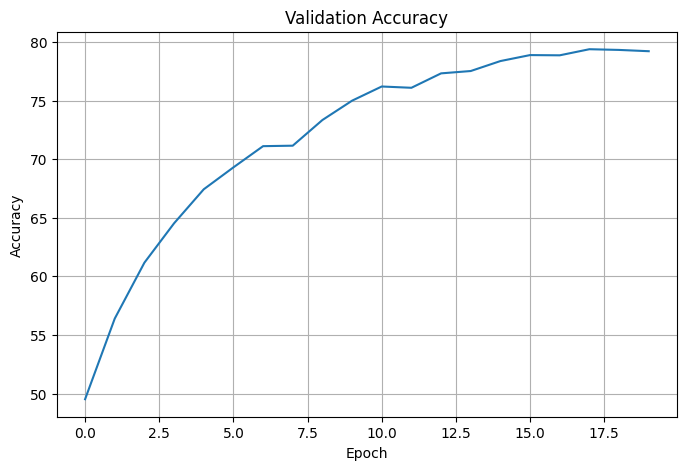

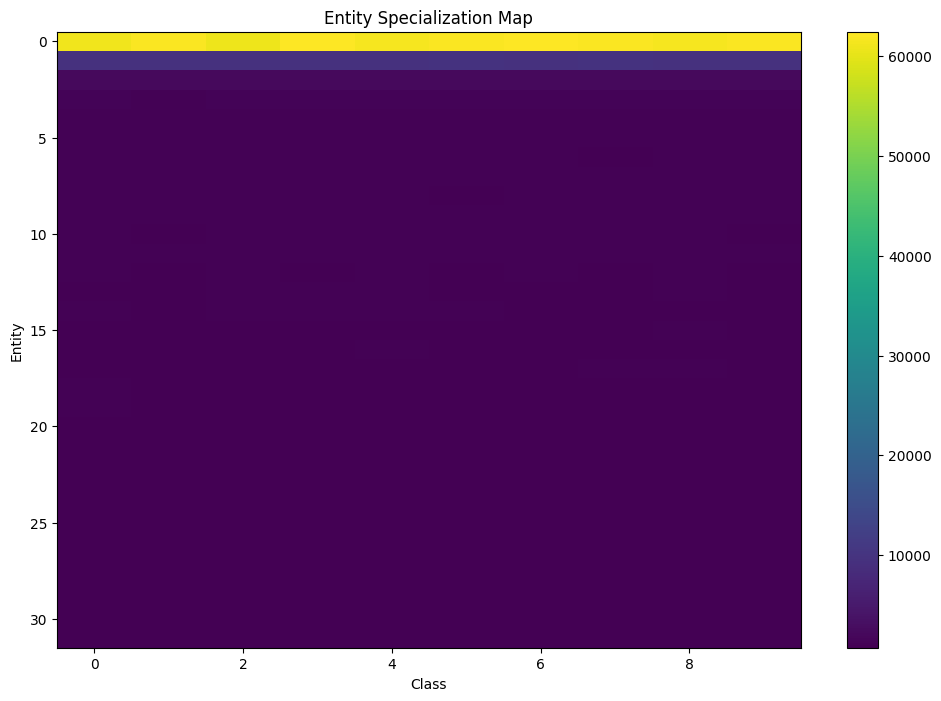

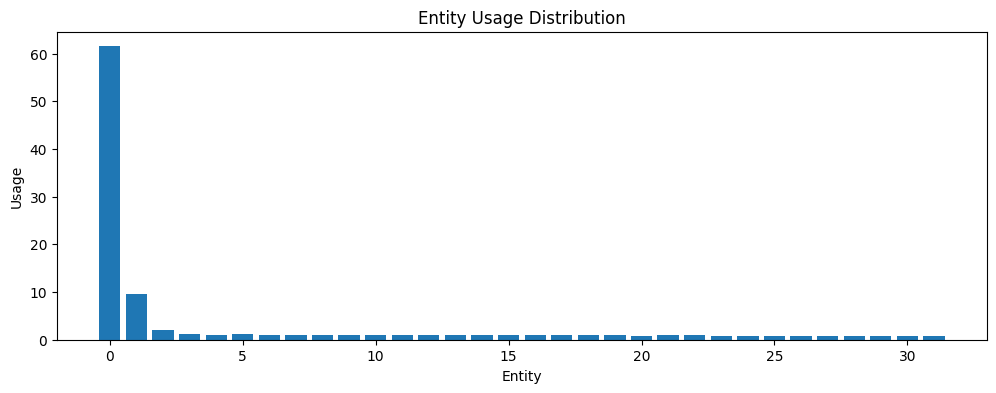

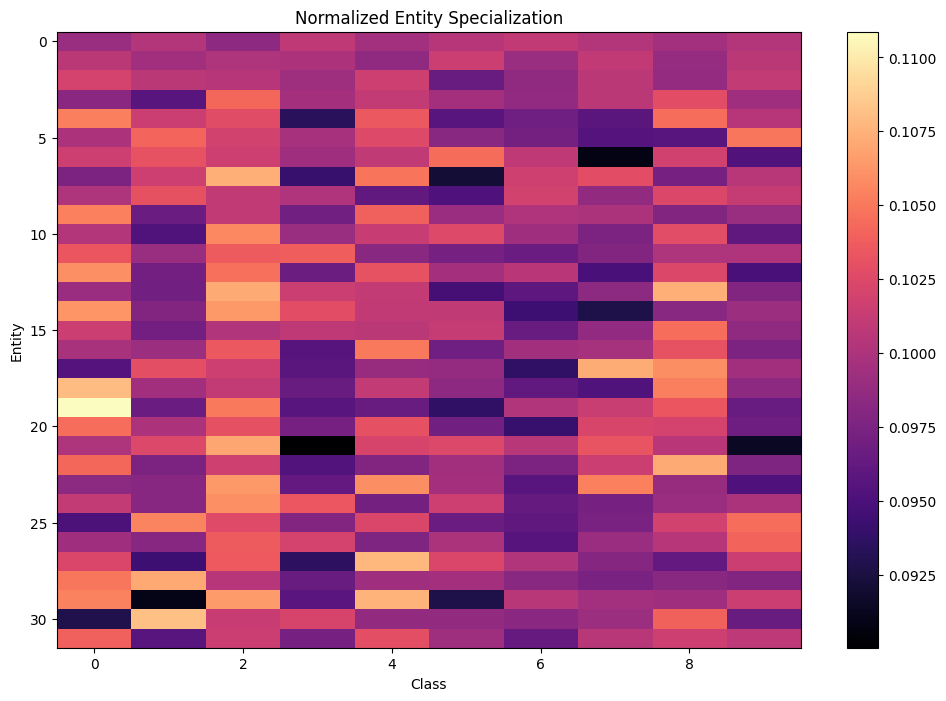


Top Entity Specializations

Entity 00 -> frog       | strength=0.101
Entity 01 -> dog        | strength=0.101
Entity 02 -> airplane   | strength=0.102
Entity 03 -> bird       | strength=0.104
Entity 04 -> airplane   | strength=0.105
Entity 05 -> truck      | strength=0.105
Entity 06 -> dog        | strength=0.104
Entity 07 -> bird       | strength=0.107
Entity 08 -> automobile | strength=0.103
Entity 09 -> airplane   | strength=0.105
Entity 10 -> bird       | strength=0.106
Entity 11 -> cat        | strength=0.104
Entity 12 -> airplane   | strength=0.106
Entity 13 -> ship       | strength=0.107
Entity 14 -> bird       | strength=0.106
Entity 15 -> ship       | strength=0.105
Entity 16 -> deer       | strength=0.105
Entity 17 -> horse      | strength=0.107
Entity 18 -> airplane   | strength=0.108
Entity 19 -> airplane   | strength=0.111
Entity 20 -> airplane   | strength=0.105
Entity 21 -> bird       | strength=0.107
Entity 22 -> ship       | strength=0.107
Entity 23 -> bird       | st

In [ ]:
# ============================================================
# SESM-v3-lite STEP 1
# Persistent Semantic Memory Core
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("DEVICE:", device)

# ============================================================
# CONFIG
# ============================================================

BATCH_SIZE = 128
EPOCHS = 20

LR = 3e-4

NUM_ENTITIES = 32
ENTITY_DIM = 128

NUM_CLASSES = 10

IMAGE_SIZE = 32

# ============================================================
# DATASET
# ============================================================

train_transform = transforms.Compose([

    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

test_transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

train_dataset = datasets.CIFAR10(
    "./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    "./data",
    train=False,
    download=True,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

# ============================================================
# CNN TOKENIZER
# ============================================================

class CNNTokenizer(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),

            nn.Conv2d(128, ENTITY_DIM, 3, stride=2, padding=1),
            nn.BatchNorm2d(ENTITY_DIM),
            nn.GELU()
        )

    def forward(self, x):

        x = self.encoder(x)

        B, C, H, W = x.shape

        # [B, C, H, W] -> [B, N, C]
        tokens = x.flatten(2).transpose(1, 2)

        return tokens

# ============================================================
# PERSISTENT ENTITY MEMORY
# ============================================================

class PersistentEntityMemory(nn.Module):

    def __init__(self):

        super().__init__()

        # ----------------------------------------------------
        # learnable semantic identity
        # ----------------------------------------------------

        self.entity_identity = nn.Parameter(

            torch.randn(
                NUM_ENTITIES,
                ENTITY_DIM
            ) * 0.02
        )

        # ----------------------------------------------------
        # persistent semantic state
        # ----------------------------------------------------

        self.register_buffer(

            "entity_state",

            F.normalize(
                torch.randn(
                    NUM_ENTITIES,
                    ENTITY_DIM
                ),
                dim=-1
            )
        )

        # ----------------------------------------------------
        # positional embeddings
        # tokenizer output:
        # 32x32 -> 16x16 -> 8x8
        # therefore 64 spatial tokens
        # ----------------------------------------------------

        self.pos_embed = nn.Parameter(

            torch.randn(
                1,
                64,
                ENTITY_DIM
            ) * 0.02
        )

        # ----------------------------------------------------
        # cross attention
        # entities query image tokens
        # ----------------------------------------------------

        self.cross_attention = nn.MultiheadAttention(

            embed_dim=ENTITY_DIM,
            num_heads=4,
            batch_first=True
        )

        # ----------------------------------------------------
        # reasoning block
        # ----------------------------------------------------

        self.reason = nn.Sequential(

            nn.Linear(ENTITY_DIM, ENTITY_DIM),

            nn.GELU(),

            nn.Linear(ENTITY_DIM, ENTITY_DIM)
        )

        # ----------------------------------------------------
        # classifier
        # ----------------------------------------------------

        self.head = nn.Sequential(

            nn.LayerNorm(ENTITY_DIM),

            nn.Linear(
                ENTITY_DIM,
                NUM_CLASSES
            )
        )

        # ----------------------------------------------------
        # statistics tracking
        # ----------------------------------------------------

        self.register_buffer(

            "usage",

            torch.zeros(NUM_ENTITIES)
        )

        self.register_buffer(

            "specialization",

            torch.zeros(
                NUM_ENTITIES,
                NUM_CLASSES
            )
        )

        # ----------------------------------------------------
        # EMA memory coefficient
        # ----------------------------------------------------

        self.memory_alpha = 0.98

    # ========================================================
    # FORWARD
    # ========================================================

    def forward(self, tokens, labels=None):

        B, N, C = tokens.shape

        # ----------------------------------------------------
        # positional embeddings
        # ----------------------------------------------------

        tokens = tokens + self.pos_embed[:, :N]

        # ----------------------------------------------------
        # persistent entities
        # ----------------------------------------------------

        persistent_entities = (

            self.entity_identity +
            self.entity_state
        )

        persistent_entities = F.normalize(
            persistent_entities,
            dim=-1
        )

        # expand to batch
        persistent_entities = (

            persistent_entities
            .unsqueeze(0)
            .expand(B, -1, -1)
        )

        # ----------------------------------------------------
        # entities attend to tokens
        # ----------------------------------------------------

        updated_entities, attention = self.cross_attention(

            query=persistent_entities,
            key=tokens,
            value=tokens
        )

        # attention shape:
        # [B, entities, tokens]

        # ----------------------------------------------------
        # residual reasoning
        # ----------------------------------------------------

        updated_entities = (

            updated_entities +
            self.reason(updated_entities)
        )

        updated_entities = F.normalize(
            updated_entities,
            dim=-1
        )

        # ----------------------------------------------------
        # EMA MEMORY UPDATE
        # ----------------------------------------------------

        with torch.no_grad():

            mean_update = F.normalize(

                updated_entities.mean(dim=0),

                dim=-1
            )

            self.entity_state *= self.memory_alpha

            self.entity_state += (

                (1 - self.memory_alpha)
                * mean_update
            )

            self.entity_state = F.normalize(
                self.entity_state,
                dim=-1
            )

        # ----------------------------------------------------
        # ENTITY USAGE TRACKING
        # ----------------------------------------------------

        # average attention over tokens
        # -> [B, entities]

        entity_strength = attention.mean(dim=-1)

        # dominant entity per sample

        dominant = entity_strength.argmax(dim=-1)

        with torch.no_grad():

            self.usage *= 0.99

            counts = torch.bincount(

                dominant,

                minlength=NUM_ENTITIES
            ).float()

            counts /= (
                counts.sum() + 1e-8
            )

            self.usage += counts

        # ----------------------------------------------------
        # SPECIALIZATION TRACKING
        # ----------------------------------------------------

        if labels is not None:

            with torch.no_grad():

                for i in range(B):

                    ent = dominant[i]
                    cls = labels[i]

                    self.specialization[
                        ent,
                        cls
                    ] += 1

        # ----------------------------------------------------
        # GLOBAL SEMANTIC CONSENSUS
        # ----------------------------------------------------

        # max pooling encourages specialization

        global_state = (
            updated_entities
            .max(dim=1)
            .values
        )

        logits = self.head(global_state)

        return logits, attention

# ============================================================
# SESM MODEL
# ============================================================

class SESM(nn.Module):

    def __init__(self):

        super().__init__()

        self.tokenizer = CNNTokenizer()

        self.memory = PersistentEntityMemory()

    def forward(self, x, labels=None):

        tokens = self.tokenizer(x)

        logits, attention = self.memory(
            tokens,
            labels
        )

        return logits, attention

# ============================================================
# MODEL SETUP
# ============================================================

model = SESM().to(device)

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LR,

    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=EPOCHS
)

criterion = nn.CrossEntropyLoss()

print("Model initialized.")

# ============================================================
# TRAINING
# ============================================================

history = []

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits, attention = model(
            images,
            labels
        )

        # ----------------------------------------------------
        # classification loss
        # ----------------------------------------------------

        loss = criterion(
            logits,
            labels
        )

        # ----------------------------------------------------
        # usage balancing regularization
        # ----------------------------------------------------

        usage = model.memory.usage

        usage = usage / (
            usage.sum() + 1e-8
        )

        uniform = torch.ones_like(usage)

        uniform /= uniform.sum()

        balance_loss = F.kl_div(

            torch.log(usage + 1e-8),

            uniform,

            reduction="batchmean"
        )

        loss += 0.001 * balance_loss

        # ----------------------------------------------------
        # optimization
        # ----------------------------------------------------

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        # ----------------------------------------------------
        # statistics
        # ----------------------------------------------------

        total_loss += loss.item()

        preds = logits.argmax(dim=1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    scheduler.step()

    train_acc = 100 * correct / total

    # ========================================================
    # EVALUATION
    # ========================================================

    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            logits, _ = model(images)

            preds = logits.argmax(dim=1)

            val_correct += (
                preds == labels
            ).sum().item()

            val_total += labels.size(0)

    val_acc = 100 * val_correct / val_total

    avg_loss = total_loss / len(train_loader)

    print(

        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {avg_loss:.4f} | "
        f"Train: {train_acc:.2f}% | "
        f"Val: {val_acc:.2f}%"
    )

    history.append(val_acc)

# ============================================================
# VALIDATION ACCURACY CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(history)

plt.title("Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

# ============================================================
# ENTITY SPECIALIZATION MAP
# ============================================================

spec = model.memory.specialization.cpu().numpy()

plt.figure(figsize=(12, 8))

plt.imshow(
    spec,
    aspect='auto',
    cmap='viridis'
)

plt.colorbar()

plt.xlabel("Class")
plt.ylabel("Entity")

plt.title("Entity Specialization Map")

plt.show()

# ============================================================
# ENTITY USAGE
# ============================================================

usage = model.memory.usage.cpu().numpy()

plt.figure(figsize=(12, 4))

plt.bar(

    np.arange(NUM_ENTITIES),

    usage
)

plt.title("Entity Usage Distribution")

plt.xlabel("Entity")

plt.ylabel("Usage")

plt.show()

# ============================================================
# NORMALIZED SPECIALIZATION
# easier to interpret
# ============================================================

norm_spec = spec / (
    spec.sum(axis=1, keepdims=True) + 1e-8
)

plt.figure(figsize=(12, 8))

plt.imshow(

    norm_spec,

    aspect='auto',

    cmap='magma'
)

plt.colorbar()

plt.xlabel("Class")

plt.ylabel("Entity")

plt.title("Normalized Entity Specialization")

plt.show()

# ============================================================
# PRINT TOP SPECIALIZED CLASS PER ENTITY
# ============================================================

class_names = train_dataset.classes

print("\nTop Entity Specializations\n")

for ent in range(NUM_ENTITIES):

    cls = norm_spec[ent].argmax()

    score = norm_spec[ent][cls]

    print(

        f"Entity {ent:02d} -> "
        f"{class_names[cls]:10s} | "
        f"strength={score:.3f}"
    )

#Step 2 CODE

DEVICE: cuda
Model initialized.
Epoch [1/20] | Loss: 1.6017 | Train: 40.72% | Val: 49.94%
Epoch [2/20] | Loss: 1.2993 | Train: 52.71% | Val: 55.46%
Epoch [3/20] | Loss: 1.1481 | Train: 58.93% | Val: 60.68%
Epoch [4/20] | Loss: 1.0416 | Train: 62.94% | Val: 63.39%
Epoch [5/20] | Loss: 0.9654 | Train: 65.87% | Val: 66.78%
Epoch [6/20] | Loss: 0.9060 | Train: 68.00% | Val: 69.39%
Epoch [7/20] | Loss: 0.8512 | Train: 70.07% | Val: 69.95%
Epoch [8/20] | Loss: 0.8088 | Train: 71.28% | Val: 72.56%
Epoch [9/20] | Loss: 0.7697 | Train: 72.94% | Val: 72.14%
Epoch [10/20] | Loss: 0.7425 | Train: 73.98% | Val: 74.60%
Epoch [11/20] | Loss: 0.7083 | Train: 75.15% | Val: 74.64%
Epoch [12/20] | Loss: 0.6799 | Train: 76.28% | Val: 75.91%
Epoch [13/20] | Loss: 0.6553 | Train: 77.06% | Val: 77.28%
Epoch [14/20] | Loss: 0.6344 | Train: 77.92% | Val: 77.23%
Epoch [15/20] | Loss: 0.6157 | Train: 78.57% | Val: 77.04%
Epoch [16/20] | Loss: 0.5994 | Train: 79.07% | Val: 77.86%
Epoch [17/20] | Loss: 0.5902 | Tr

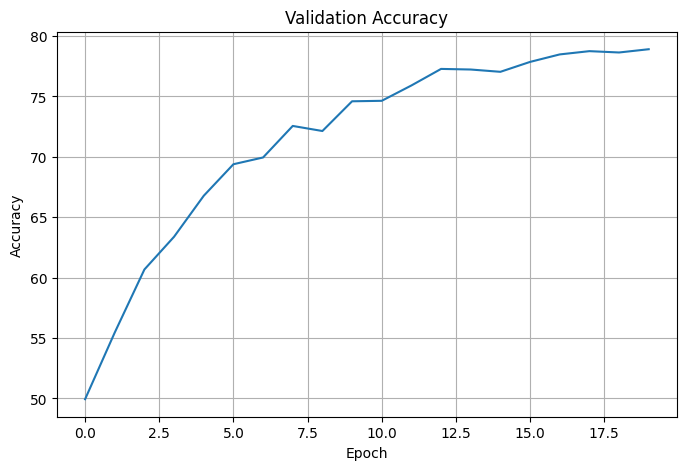

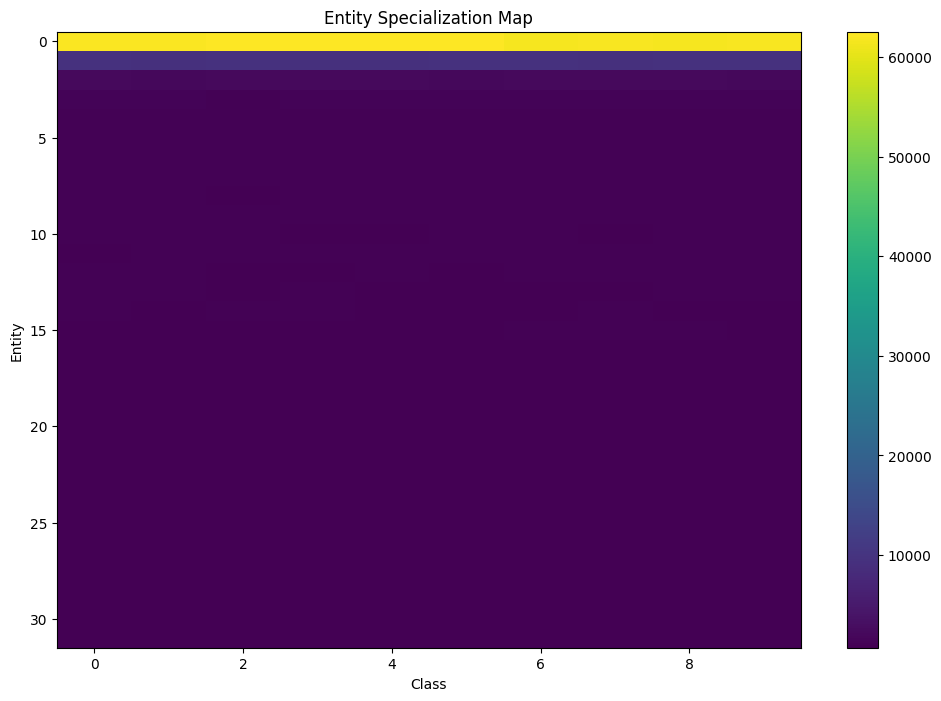

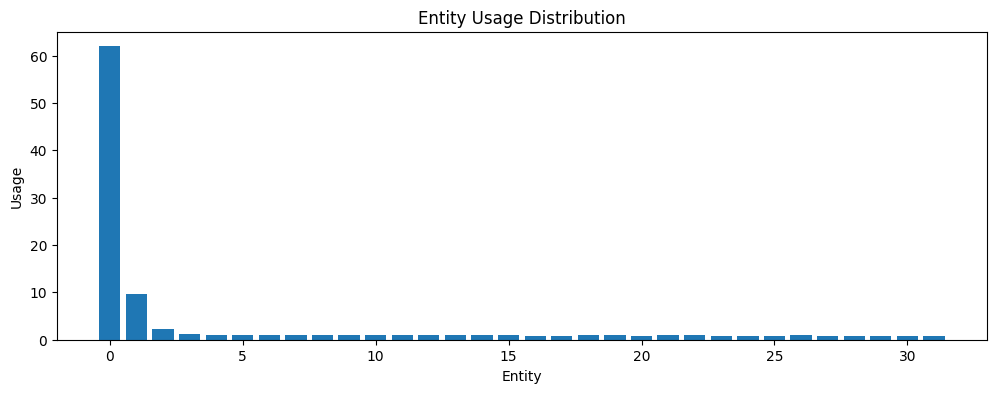

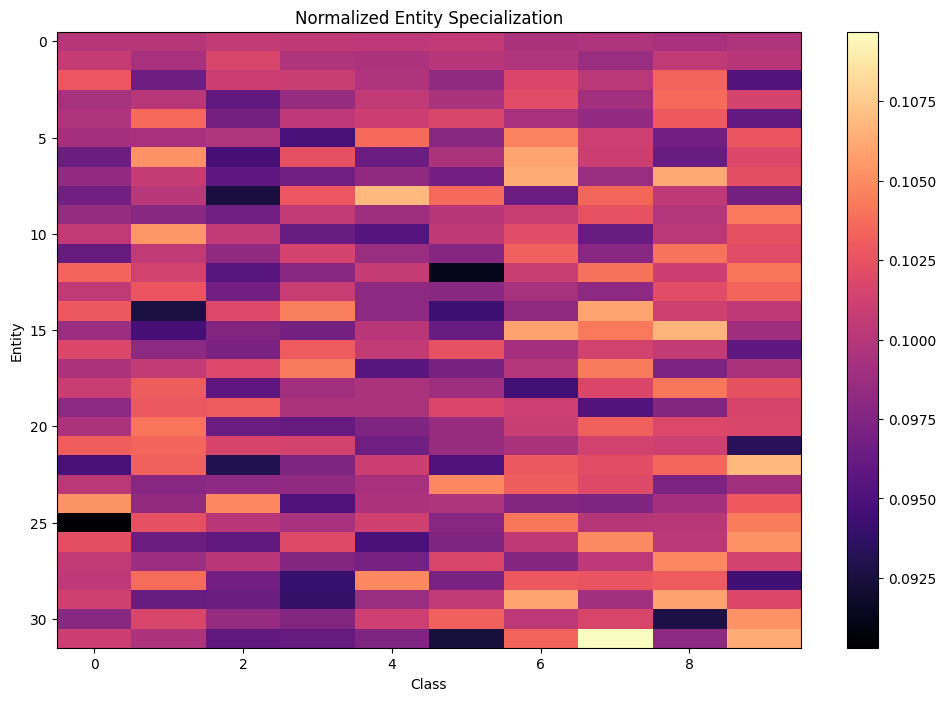


Top Entity Specializations

Entity 00 -> bird       | strength=0.101
Entity 01 -> bird       | strength=0.102
Entity 02 -> ship       | strength=0.103
Entity 03 -> ship       | strength=0.104
Entity 04 -> automobile | strength=0.104
Entity 05 -> frog       | strength=0.105
Entity 06 -> frog       | strength=0.106
Entity 07 -> frog       | strength=0.106
Entity 08 -> deer       | strength=0.107
Entity 09 -> truck      | strength=0.104
Entity 10 -> automobile | strength=0.105
Entity 11 -> ship       | strength=0.104
Entity 12 -> truck      | strength=0.104
Entity 13 -> truck      | strength=0.103
Entity 14 -> horse      | strength=0.106
Entity 15 -> ship       | strength=0.107
Entity 16 -> cat        | strength=0.103
Entity 17 -> cat        | strength=0.104
Entity 18 -> ship       | strength=0.104
Entity 19 -> bird       | strength=0.103
Entity 20 -> automobile | strength=0.104
Entity 21 -> automobile | strength=0.103
Entity 22 -> truck      | strength=0.107
Entity 23 -> dog        | st

In [ ]:
# ============================================================
# SESM-v3-lite STEP 2
# Iterative Persistent Semantic Memory
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("DEVICE:", device)

# ============================================================
# CONFIG
# ============================================================

BATCH_SIZE = 128
EPOCHS = 20

LR = 3e-4

NUM_ENTITIES = 32
ENTITY_DIM = 128

NUM_CLASSES = 10

IMAGE_SIZE = 32

# ============================================================
# DATASET
# ============================================================

train_transform = transforms.Compose([

    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

test_transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

train_dataset = datasets.CIFAR10(
    "./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    "./data",
    train=False,
    download=True,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

# ============================================================
# CNN TOKENIZER
# ============================================================

class CNNTokenizer(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),

            nn.Conv2d(128, ENTITY_DIM, 3, stride=2, padding=1),
            nn.BatchNorm2d(ENTITY_DIM),
            nn.GELU()
        )

    def forward(self, x):

        x = self.encoder(x)

        B, C, H, W = x.shape

        # [B, C, H, W] -> [B, N, C]
        tokens = x.flatten(2).transpose(1, 2)

        return tokens

# ============================================================
# PERSISTENT ENTITY MEMORY v2
# Iterative Semantic Refinement
# ============================================================

class PersistentEntityMemory(nn.Module):

    def __init__(self):

        super().__init__()

        # ----------------------------------------------------
        # learnable semantic identity
        # ----------------------------------------------------

        self.entity_identity = nn.Parameter(

            torch.randn(
                NUM_ENTITIES,
                ENTITY_DIM
            ) * 0.02
        )

        # ----------------------------------------------------
        # persistent memory state
        # ----------------------------------------------------

        self.register_buffer(

            "entity_state",

            F.normalize(
                torch.randn(
                    NUM_ENTITIES,
                    ENTITY_DIM
                ),
                dim=-1
            )
        )

        # ----------------------------------------------------
        # positional embeddings
        # ----------------------------------------------------

        self.pos_embed = nn.Parameter(

            torch.randn(
                1,
                64,
                ENTITY_DIM
            ) * 0.02
        )

        # ----------------------------------------------------
        # token -> entity interaction
        # ----------------------------------------------------

        self.cross_attention = nn.MultiheadAttention(

            embed_dim=ENTITY_DIM,
            num_heads=4,
            batch_first=True
        )

        # ----------------------------------------------------
        # entity -> entity interaction
        # ----------------------------------------------------

        self.entity_self_attention = nn.MultiheadAttention(

            embed_dim=ENTITY_DIM,
            num_heads=4,
            batch_first=True
        )

        # ----------------------------------------------------
        # learned memory updater
        # ----------------------------------------------------

        self.memory_gru = nn.GRUCell(
            ENTITY_DIM,
            ENTITY_DIM
        )

        # ----------------------------------------------------
        # reasoning block
        # ----------------------------------------------------

        self.reason = nn.Sequential(

            nn.Linear(
                ENTITY_DIM,
                ENTITY_DIM * 2
            ),

            nn.GELU(),

            nn.Linear(
                ENTITY_DIM * 2,
                ENTITY_DIM
            )
        )

        # ----------------------------------------------------
        # classifier
        # ----------------------------------------------------

        self.head = nn.Sequential(

            nn.LayerNorm(ENTITY_DIM),

            nn.Linear(
                ENTITY_DIM,
                NUM_CLASSES
            )
        )

        # ----------------------------------------------------
        # statistics
        # ----------------------------------------------------

        self.register_buffer(
            "usage",
            torch.zeros(NUM_ENTITIES)
        )

        self.register_buffer(

            "specialization",

            torch.zeros(
                NUM_ENTITIES,
                NUM_CLASSES
            )
        )

        # ----------------------------------------------------
        # refinement steps
        # ----------------------------------------------------

        self.refine_steps = 3

    # ========================================================
    # FORWARD
    # ========================================================

    def forward(self, tokens, labels=None):

        B, N, C = tokens.shape

        # ----------------------------------------------------
        # positional encoding
        # ----------------------------------------------------

        tokens = tokens + self.pos_embed[:, :N]

        # ----------------------------------------------------
        # persistent semantic entities
        # ----------------------------------------------------

        base_entities = (

            self.entity_identity +
            self.entity_state
        )

        base_entities = F.normalize(
            base_entities,
            dim=-1
        )

        entities = (
            base_entities
            .unsqueeze(0)
            .expand(B, -1, -1)
        )

        # ====================================================
        # ITERATIVE SEMANTIC REFINEMENT
        # ====================================================

        for _ in range(self.refine_steps):

            # ------------------------------------------------
            # entities attend to image tokens
            # ------------------------------------------------

            queried, attention = self.cross_attention(

                query=entities,
                key=tokens,
                value=tokens
            )

            # residual update
            entities = entities + queried

            # ------------------------------------------------
            # entity communication
            # ------------------------------------------------

            interacted, _ = self.entity_self_attention(

                entities,
                entities,
                entities
            )

            entities = entities + interacted

            # ------------------------------------------------
            # reasoning
            # ------------------------------------------------

            entities = entities + self.reason(
                entities
            )

            entities = F.normalize(
                entities,
                dim=-1
            )

        # ====================================================
        # MEMORY CONSOLIDATION
        # ====================================================

        with torch.no_grad():

            mean_entities = entities.mean(dim=0)

            updated_memory = self.memory_gru(

                mean_entities.reshape(
                    -1,
                    ENTITY_DIM
                ),

                self.entity_state.reshape(
                    -1,
                    ENTITY_DIM
                )
            )

            updated_memory = F.normalize(
                updated_memory,
                dim=-1
            )

            self.entity_state.copy_(
                updated_memory
            )

        # ====================================================
        # ENTITY USAGE
        # ====================================================

        entity_strength = attention.mean(dim=-1)

        dominant = entity_strength.argmax(dim=-1)

        with torch.no_grad():

            self.usage *= 0.99

            counts = torch.bincount(

                dominant,

                minlength=NUM_ENTITIES
            ).float()

            counts /= (
                counts.sum() + 1e-8
            )

            self.usage += counts

        # ====================================================
        # SPECIALIZATION TRACKING
        # ====================================================

        if labels is not None:

            with torch.no_grad():

                for i in range(B):

                    ent = dominant[i]
                    cls = labels[i]

                    self.specialization[
                        ent,
                        cls
                    ] += 1

        # ====================================================
        # GLOBAL CONSENSUS
        # ====================================================

        # attention-weighted pooling

        weights = F.softmax(
            entity_strength,
            dim=-1
        )

        global_state = (

            weights.unsqueeze(-1)
            * entities
        ).sum(dim=1)

        logits = self.head(global_state)

        return logits, attention

# ============================================================
# SESM MODEL
# ============================================================

class SESM(nn.Module):

    def __init__(self):

        super().__init__()

        self.tokenizer = CNNTokenizer()

        self.memory = PersistentEntityMemory()

    def forward(self, x, labels=None):

        tokens = self.tokenizer(x)

        logits, attention = self.memory(
            tokens,
            labels
        )

        return logits, attention

# ============================================================
# MODEL SETUP
# ============================================================

model = SESM().to(device)

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LR,

    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=EPOCHS
)

criterion = nn.CrossEntropyLoss()

print("Model initialized.")

# ============================================================
# TRAINING
# ============================================================

history = []

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits, attention = model(
            images,
            labels
        )

        # ----------------------------------------------------
        # classification loss
        # ----------------------------------------------------

        loss = criterion(
            logits,
            labels
        )

        # ----------------------------------------------------
        # usage balancing regularization
        # ----------------------------------------------------

        usage = model.memory.usage

        usage = usage / (
            usage.sum() + 1e-8
        )

        uniform = torch.ones_like(usage)

        uniform /= uniform.sum()

        balance_loss = F.kl_div(

            torch.log(usage + 1e-8),

            uniform,

            reduction="batchmean"
        )

        # reduced balancing pressure
        loss += 0.0003 * balance_loss

        # ----------------------------------------------------
        # optimization
        # ----------------------------------------------------

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        # ----------------------------------------------------
        # statistics
        # ----------------------------------------------------

        total_loss += loss.item()

        preds = logits.argmax(dim=1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    scheduler.step()

    train_acc = 100 * correct / total

    # ========================================================
    # EVALUATION
    # ========================================================

    model.eval()

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            logits, _ = model(images)

            preds = logits.argmax(dim=1)

            val_correct += (
                preds == labels
            ).sum().item()

            val_total += labels.size(0)

    val_acc = 100 * val_correct / val_total

    avg_loss = total_loss / len(train_loader)

    print(

        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Loss: {avg_loss:.4f} | "
        f"Train: {train_acc:.2f}% | "
        f"Val: {val_acc:.2f}%"
    )

    history.append(val_acc)

# ============================================================
# VALIDATION ACCURACY CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(history)

plt.title("Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

# ============================================================
# ENTITY SPECIALIZATION MAP
# ============================================================

spec = model.memory.specialization.cpu().numpy()

plt.figure(figsize=(12, 8))

plt.imshow(
    spec,
    aspect='auto',
    cmap='viridis'
)

plt.colorbar()

plt.xlabel("Class")
plt.ylabel("Entity")

plt.title("Entity Specialization Map")

plt.show()

# ============================================================
# ENTITY USAGE
# ============================================================

usage = model.memory.usage.cpu().numpy()

plt.figure(figsize=(12, 4))

plt.bar(

    np.arange(NUM_ENTITIES),

    usage
)

plt.title("Entity Usage Distribution")

plt.xlabel("Entity")

plt.ylabel("Usage")

plt.show()

# ============================================================
# NORMALIZED SPECIALIZATION
# ============================================================

norm_spec = spec / (
    spec.sum(axis=1, keepdims=True) + 1e-8
)

plt.figure(figsize=(12, 8))

plt.imshow(

    norm_spec,

    aspect='auto',

    cmap='magma'
)

plt.colorbar()

plt.xlabel("Class")

plt.ylabel("Entity")

plt.title("Normalized Entity Specialization")

plt.show()

# ============================================================
# PRINT TOP SPECIALIZED CLASS PER ENTITY
# ============================================================

class_names = train_dataset.classes

print("\nTop Entity Specializations\n")

for ent in range(NUM_ENTITIES):

    cls = norm_spec[ent].argmax()

    score = norm_spec[ent][cls]

    print(

        f"Entity {ent:02d} -> "
        f"{class_names[cls]:10s} | "
        f"strength={score:.3f}"
    )